In [90]:
import os
from pathlib import Path
import sys

BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

PROCESSED_DIR = BASE_DIR / "data"/ "processed"

processed_paths_dict = { 
    "beta": os.path.join(PROCESSED_DIR, "beta.parquet"),
    "mean_volatility": os.path.join(PROCESSED_DIR, "mean_volatility.parquet"),
    "microstructure": os.path.join(PROCESSED_DIR, "microstructure.parquet"),
    "momentum": os.path.join(PROCESSED_DIR, "momentum.parquet"),
    "momentum_liquidity": os.path.join(PROCESSED_DIR, "momentum_liquidity.parquet"),
    "pvo": os.path.join(PROCESSED_DIR, "pvo.parquet"), 
    "reversal": os.path.join(PROCESSED_DIR, "reversal.parquet"),
    "reversal_illiquidity": os.path.join(PROCESSED_DIR, "reversal_illiquidity.parquet")
}

In [91]:
BASE_DIR

WindowsPath('c:/Users/Gordon Li/Desktop/systematic_project')

In [92]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns

from scripts.research.ic import IC
from scripts.research.quintile import Quintile
from scripts.research.plots import (
    plot_ic_timeseries, 
    plot_ic_summary_bar, 
    plot_quintiles, 
    plot_correlation
)
from scripts.research.utils import summary_plot_final_df
from scripts.research.targets import ForwardReturns

## Forward Returns

In [93]:
returns_df = ForwardReturns([5, 10, 21]).run_data()

factors_df_dict = {}
for key, path in processed_paths_dict.items(): 
    factors_df_dict[key] = pd.read_parquet(path)

In [94]:
results_ic_dict, summary_ic_dict = dict(), dict()
for factor, df in factors_df_dict.items(): 
    results_ic_dict[factor], summary_ic_dict[factor] = IC(returns_df, factors_df_dict[factor]).run_data()

In [95]:
results_quintile_dict, summary_quintile_dict, spread_df_dict = dict(), dict(), dict()
for factor, df in factors_df_dict.items(): 
    results_quintile_dict[factor], summary_quintile_dict[factor], spread_df_dict[factor] = Quintile(returns_df, factors_df_dict[factor]).run_data()

## Beta

### Information Coefficient

In [7]:
beta_results_ic_dict, beta_summary_ic_df = results_ic_dict["beta"], summary_ic_dict["beta"]

#### A plot of the time series of `Beta` category signals

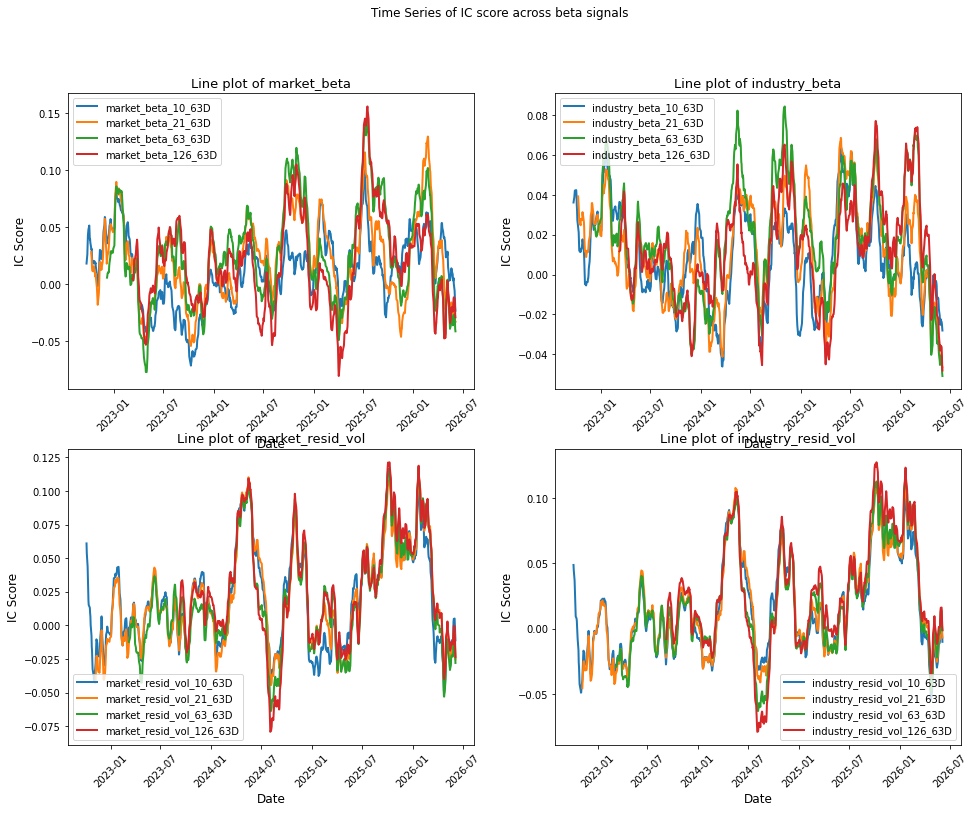

In [8]:
plot_ic_timeseries(beta_results_ic_dict, "beta")

#### A plot of the summary bar plot of `Beta` category signals

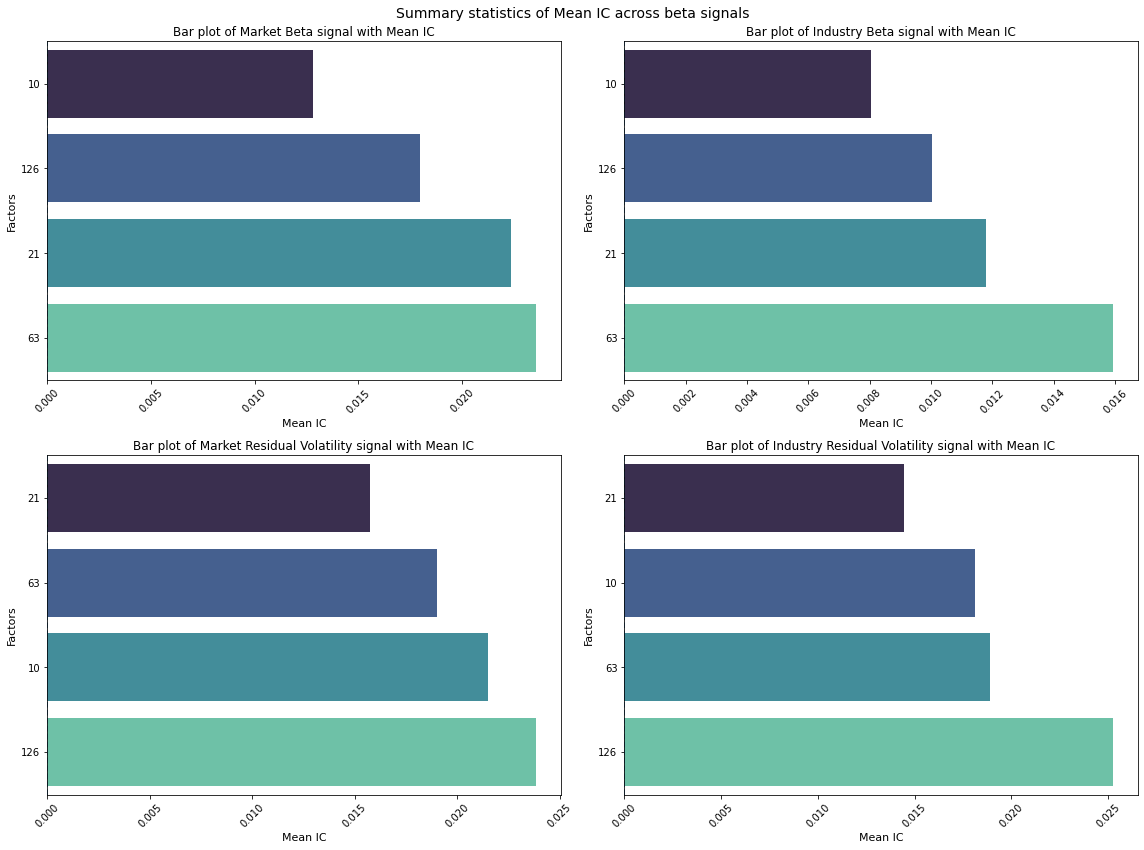

In [9]:
beta_name_dict = { 
    "market_beta": "Market Beta", 
    "industry_beta": "Industry Beta", 
    "market_resid_vol": "Market Residual Volatility", 
    "industry_resid_vol": "Industry Residual Volatility"
}

plot_beta_summary_ic_df = summary_plot_final_df(beta_summary_ic_df)


plot_ic_summary_bar(beta_results_ic_dict, plot_beta_summary_ic_df, beta_name_dict, "beta", metric="mean_ic")

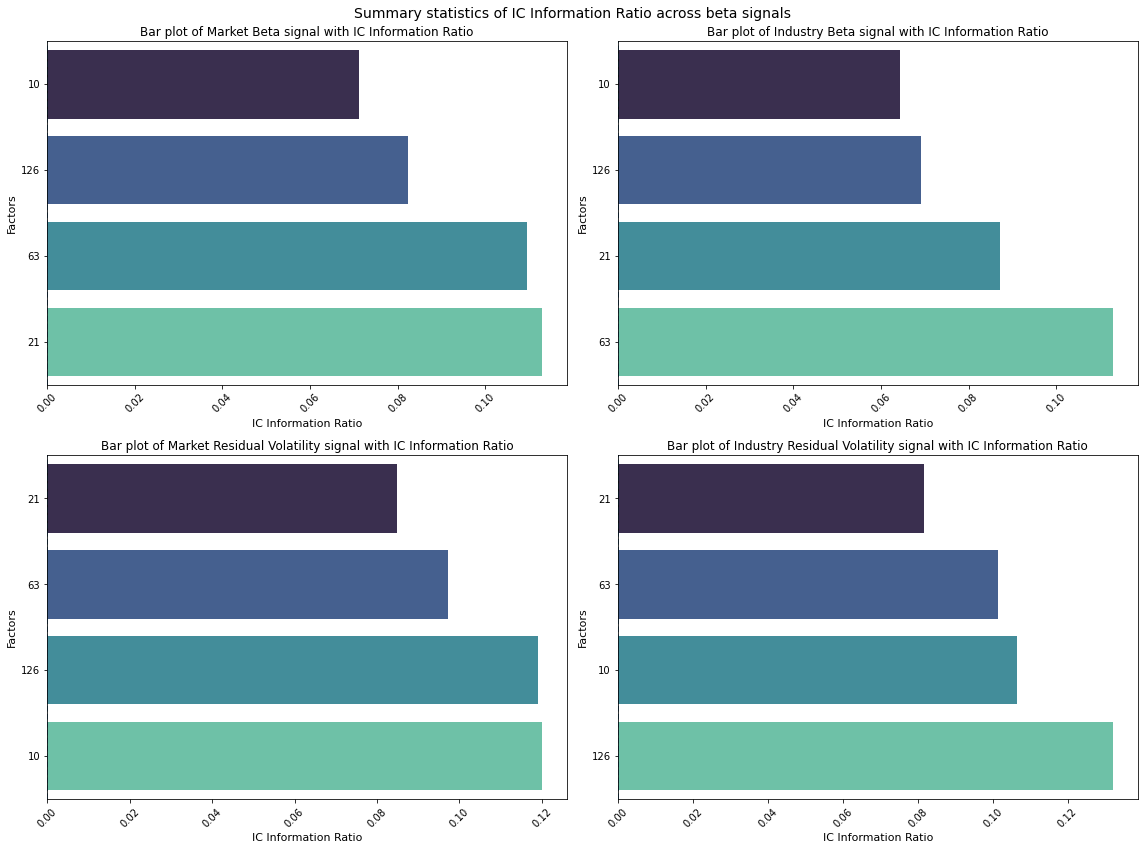

In [10]:
plot_ic_summary_bar(beta_results_ic_dict, plot_beta_summary_ic_df, beta_name_dict, "beta", metric="ic_ir")

In [11]:
beta_summary_ic_df

,Factors,mean_ic,std_ic,ic_ir,positive_ic_rate,nw_t_stat,nw_p_value,n_periods,fdr_p_value,significant_5pct
0,market_beta_10,0.012844,0.180502,0.071155,0.512538,1.322270,0.186078,997.0,0.212661,False
1,market_beta_21,0.022350,0.197712,0.113044,0.549696,2.034075,0.041944,986.0,0.167468,False
2,market_beta_63,0.023585,0.215269,0.109561,0.531780,1.896779,0.057857,944.0,0.167468,False
3,market_beta_126,0.018006,0.218319,0.082476,0.535755,1.362931,0.172904,881.0,0.212661,False
4,industry_beta_10,0.008036,0.124721,0.064430,0.536610,1.179820,0.238072,997.0,0.253153,False
5,industry_beta_21,0.011805,0.135552,0.087089,0.535497,1.539677,0.123639,986.0,0.197823,False
6,industry_beta_63,0.015944,0.141174,0.112937,0.556144,1.945735,0.051687,944.0,0.167468,False
7,industry_beta_126,0.010028,0.144798,0.069252,0.540295,1.142724,0.253153,881.0,0.253153,False
8,market_resid_vol_10,0.021509,0.179084,0.120106,0.556680,2.083028,0.037249,988.0,0.167468,False
9,market_resid_vol_21,0.015734,0.185510,0.084817,0.544513,1.461597,0.143852,966.0,0.209239,False


**Summary**: The beta-related signals show generally positive but modest IC performance, with no factor remaining significant after FDR correction. The time-series plots suggest strong regime dependence, with signals moving between positive and negative IC periods rather than showing stable predictive power. Within raw beta, market_beta_63 and industry_beta_63 look like the best representatives. Within residual volatility, industry_resid_vol_126 is the strongest overall, with the highest Mean IC, IC IR and positive IC rate. Compared with the other factor families, beta is more of a supporting feature group rather than a core alpha driver. Overall, I would keep a small set such as market_beta_63, industry_beta_63 and industry_resid_vol_126, then let the ML model decide whether they add value.

### Quintile Test

In [12]:
beta_results_quintile_dict, beta_summary_quintile_dict, beta_spread_df = results_quintile_dict["beta"], summary_quintile_dict["beta"], spread_df_dict["beta"]

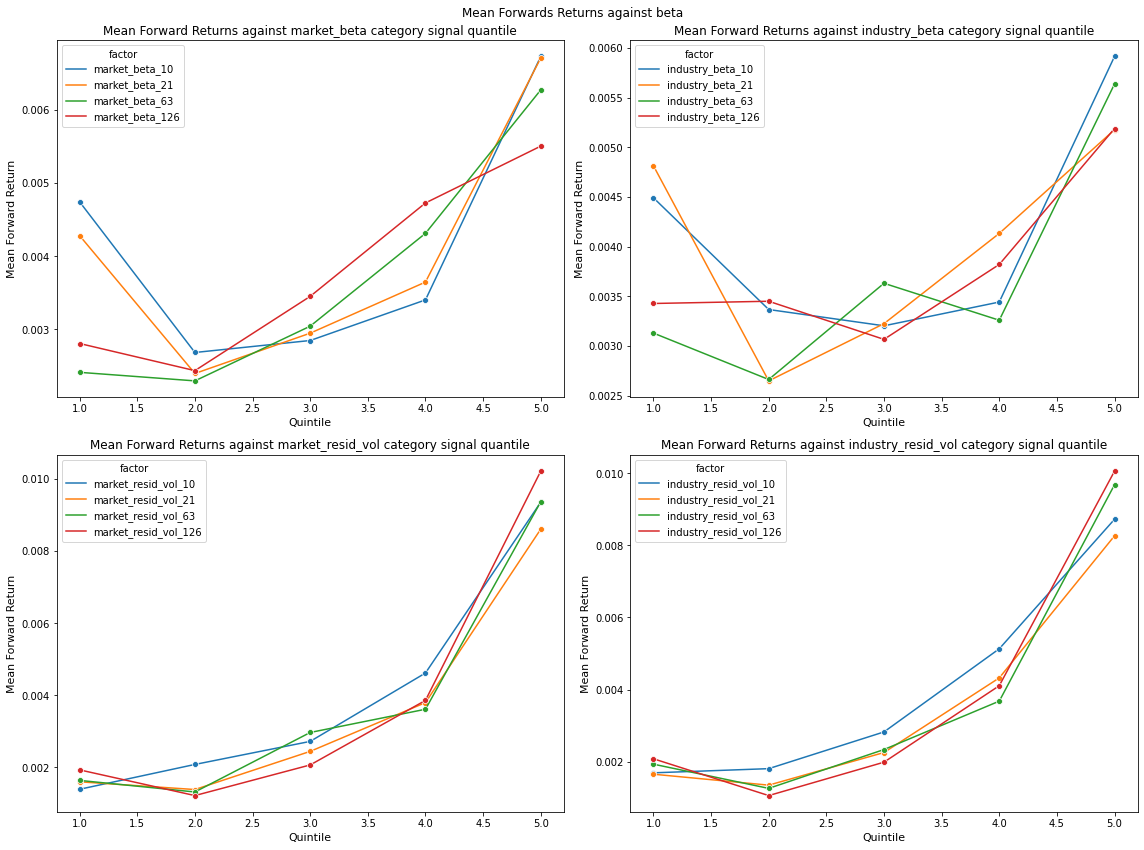

In [13]:
plot_quintiles(beta_results_quintile_dict, beta_summary_quintile_dict, "beta")

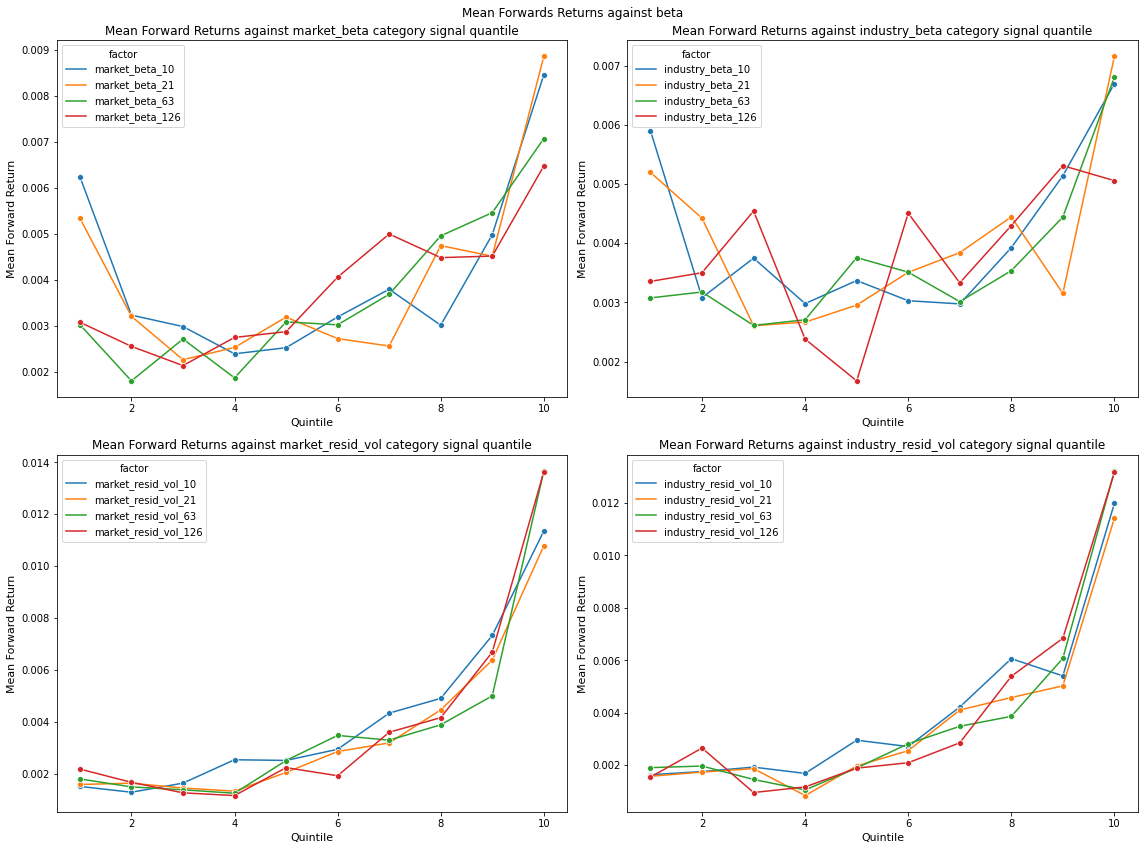

In [14]:
beta_results_quintile_dict_10, beta_summary_quintile_dict_10, beta_spread_df_10 = (
    Quintile(returns_df, factors_df_dict["beta"], 10).run_data()
)

plot_quintiles(beta_results_quintile_dict_10, beta_summary_quintile_dict_10, "beta")

#### Beta Spread Analysis

In [15]:
beta_spread_df

,market_beta_10,market_beta_21,market_beta_63,market_beta_126,industry_beta_10,industry_beta_21,industry_beta_63,industry_beta_126,market_resid_vol_10,market_resid_vol_21,market_resid_vol_63,market_resid_vol_126,industry_resid_vol_10,industry_resid_vol_21,industry_resid_vol_63,industry_resid_vol_126
factor,market_beta_10,market_beta_21,market_beta_63,market_beta_126,industry_beta_10,industry_beta_21,industry_beta_63,industry_beta_126,market_resid_vol_10,market_resid_vol_21,market_resid_vol_63,market_resid_vol_126,industry_resid_vol_10,industry_resid_vol_21,industry_resid_vol_63,industry_resid_vol_126
quintile,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1
mean_forward_return,0.001987,0.002428,0.003859,0.002697,0.001423,0.000363,0.002509,0.001762,0.007959,0.007005,0.007726,0.008283,0.007033,0.006611,0.00775,0.007978
std_forward_return,0.02677,0.028987,0.030686,0.030102,0.020244,0.021962,0.022537,0.023703,0.028236,0.028151,0.030154,0.031761,0.0267,0.027263,0.028914,0.030413
n_periods,997,986,944,881,997,986,944,881,988,966,882,756,988,966,882,756
nw_t_stat,1.387081,1.497821,2.160416,1.488996,1.311888,0.291752,1.906224,1.221657,4.836201,4.236149,4.129433,3.912801,4.518317,4.114643,4.324598,3.919194
nw_p_value,0.165417,0.13418,0.03074,0.136488,0.189558,0.770476,0.056621,0.221837,0.000001,0.000023,0.000036,0.000091,0.000006,0.000039,0.000015,0.000089


In [16]:
beta_spread_df_10

,market_beta_10,market_beta_21,market_beta_63,market_beta_126,industry_beta_10,industry_beta_21,industry_beta_63,industry_beta_126,market_resid_vol_10,market_resid_vol_21,market_resid_vol_63,market_resid_vol_126,industry_resid_vol_10,industry_resid_vol_21,industry_resid_vol_63,industry_resid_vol_126
factor,market_beta_10,market_beta_21,market_beta_63,market_beta_126,industry_beta_10,industry_beta_21,industry_beta_63,industry_beta_126,market_resid_vol_10,market_resid_vol_21,market_resid_vol_63,market_resid_vol_126,industry_resid_vol_10,industry_resid_vol_21,industry_resid_vol_63,industry_resid_vol_126
quintile,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1
mean_forward_return,0.002217,0.00352,0.004049,0.003402,0.000798,0.001959,0.00373,0.001701,0.009836,0.009197,0.011859,0.011454,0.010359,0.009851,0.011318,0.011626
std_forward_return,0.036547,0.038235,0.038953,0.039396,0.027509,0.029367,0.028435,0.029332,0.035295,0.035406,0.037966,0.041408,0.034812,0.035078,0.037299,0.039212
n_periods,997,986,944,881,997,986,944,881,988,966,882,756,988,966,882,756
nw_t_stat,1.131719,1.646528,1.782679,1.427883,0.556286,1.200722,2.270731,0.960996,4.864399,4.413447,5.02083,4.130328,5.126181,4.748147,4.885542,4.397393
nw_p_value,0.257753,0.099655,0.074639,0.153325,0.578015,0.229859,0.023163,0.336554,0.000001,0.00001,0.000001,0.000036,0.0,0.000002,0.000001,0.000011


**Summary**: The quintile and decile plots show that the residual volatility signals are much stronger than the raw beta signals. Market beta and industry beta have some positive relationship with future returns, but the patterns are noisier and the spreads are much smaller. Within raw beta, market_beta_63 is the best market beta signal, while industry_beta_63 is the best industry beta signal. The residual volatility plots are much cleaner, with returns increasing strongly from low to high quantiles. The spread analysis confirms this, with residual volatility producing Q5-Q1 spreads around 0.7–0.8% and Q10-Q1 spreads above 1.0%. These spreads are highly statistically significant across all residual volatility windows. The strongest residual volatility candidates are market_resid_vol_126 and industry_resid_vol_126, as they have the largest spreads and clearest decile separation. This suggests stock-specific volatility is more informative than broad market or industry beta exposure. Overall, keep market_beta_63 and industry_beta_63 as supporting risk features, but prioritise market_resid_vol_126 and industry_resid_vol_126 as the main beta-related predictors.

### Correlations

In [17]:
beta_factor_df = factors_df_dict["beta"]

market_beta_corr_df = beta_factor_df[["market_beta_10", "market_beta_21", "market_beta_63", "market_beta_126"]].corr("spearman")
industry_beta_corr_df = beta_factor_df[["industry_beta_10", "industry_beta_21", "industry_beta_63", "industry_beta_126"]].corr("spearman")
market_vol_corr_df = beta_factor_df[["market_resid_vol_10", "market_resid_vol_21", "market_resid_vol_63", "market_resid_vol_126"]].corr("spearman")
industry_vol_corr_df = beta_factor_df[["industry_resid_vol_10", "industry_resid_vol_21", "industry_resid_vol_63", "industry_resid_vol_126"]].corr("spearman")

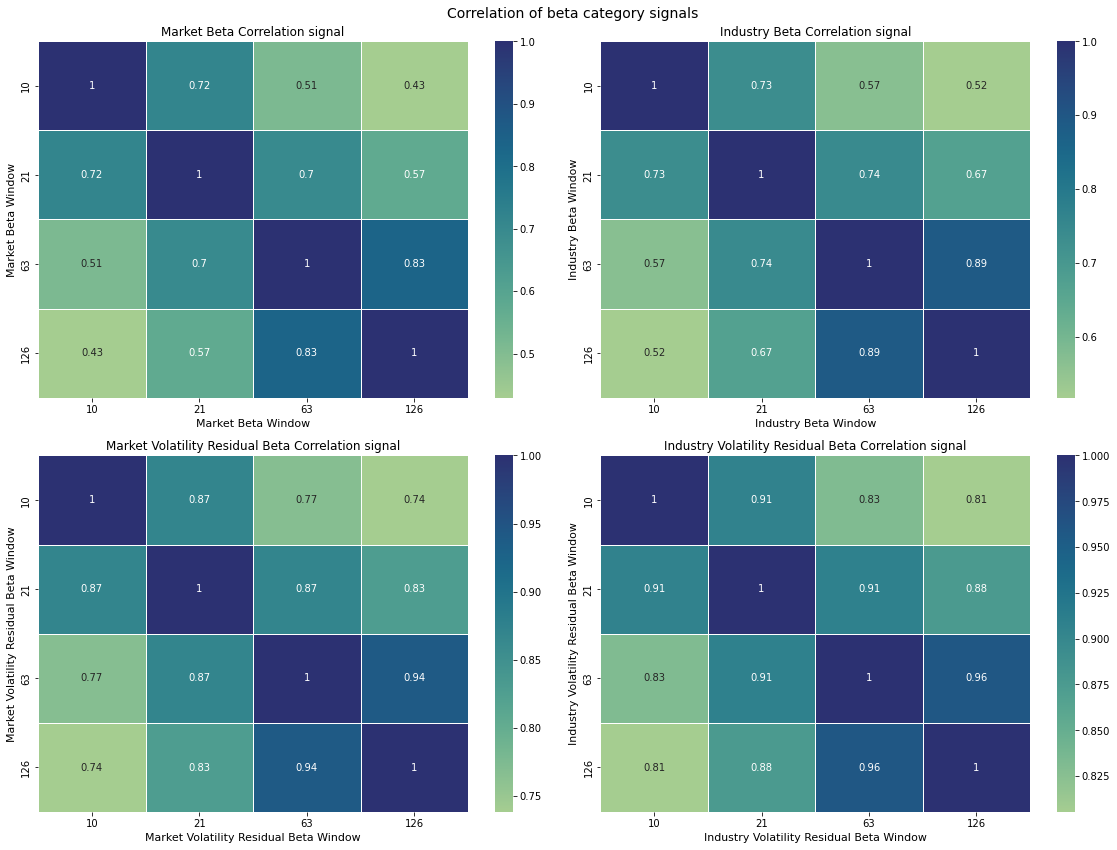

In [18]:
beta_correlations_dfs_dict = {
    "Market Beta": market_beta_corr_df, 
    "Industry Beta": industry_beta_corr_df, 
    "Market Volatility Residual Beta": market_vol_corr_df, 
    "Industry Volatility Residual Beta": industry_vol_corr_df
}

fig, axs = plot_correlation(beta_correlations_dfs_dict, "beta")

### Summary

Overall, the beta family is worth keeping, but residual volatility is much stronger than raw beta. The plots show raw beta has a mildly convex shape, where the strongest return separation occurs in the highest quantiles. Residual volatility is more monotonic, with returns rising steadily across quintiles and deciles. The spread analysis supports this, with residual volatility producing much larger and highly significant Q5-Q1 and Q10-Q1 spreads. Overall, use market_beta_63, industry_beta_63, market_resid_vol_126 and industry_resid_vol_126, with possible squared or top-decile transformations for the beta signals.

In [19]:
beta_factors = ["market_beta_63", "industry_beta_63", "market_resid_vol_126", "industry_resid_vol_126"]

## Mean Volatility

### Information Coefficient

In [20]:
mv_results_ic_dict, mv_summary_ic_df = results_ic_dict["mean_volatility"], summary_ic_dict["mean_volatility"]

#### A plot of the time series of `mean_volatility` category signals

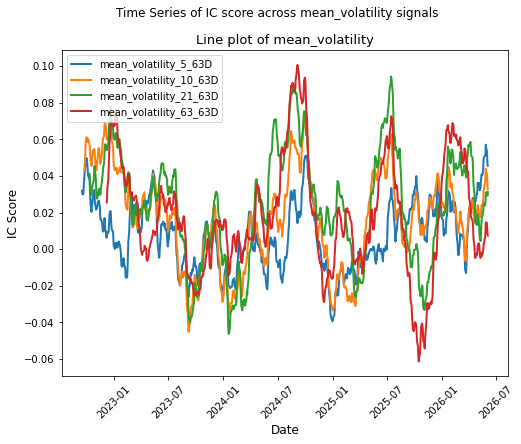

In [21]:
plot_ic_timeseries(mv_results_ic_dict, "mean_volatility")

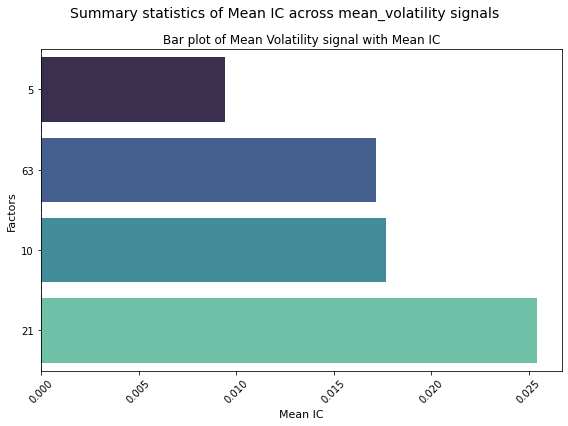

In [22]:
name_dict = { 
    "mean_volatility": "Mean Volatility"
}

plot_mv_summary_ic_df = summary_plot_final_df(mv_summary_ic_df)

plot_ic_summary_bar(mv_results_ic_dict, plot_mv_summary_ic_df, name_dict, "mean_volatility", metric="mean_ic")

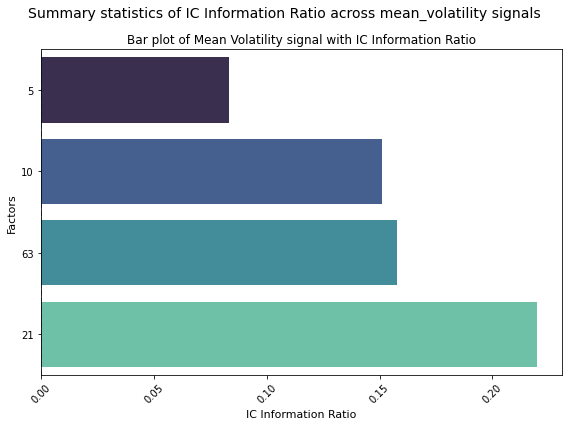

In [23]:
plot_ic_summary_bar(mv_results_ic_dict, plot_mv_summary_ic_df, name_dict, "mean_volatility", metric="ic_ir")

In [24]:
mv_summary_ic_df

,Factors,mean_ic,std_ic,ic_ir,positive_ic_rate,nw_t_stat,nw_p_value,n_periods,fdr_p_value,significant_5pct
0,mean_volatility_5,0.009453,0.113762,0.083093,0.524950,1.610990,0.107182,1002.0,0.107182,False
1,mean_volatility_10,0.017670,0.116986,0.151044,0.543631,2.759998,0.005780,997.0,0.009894,True
2,mean_volatility_21,0.025409,0.115670,0.219669,0.585193,3.799314,0.000145,986.0,0.000580,True
3,mean_volatility_63,0.017154,0.108753,0.157732,0.552966,2.677343,0.007421,944.0,0.009894,True


**Summary**: The IC time series shows that mean volatility is generally positive across horizons, but its strength changes over time, with stronger periods around mid-2024 and mid-2025 and weaker or negative periods around early 2024 and late 2025. The 5-day signal is the noisiest and often moves around zero, while the 21-day signal appears smoother, stronger, and more consistently positive. The summary plots support this, with mean_volatility_21 having the highest mean IC and IC information ratio, making it the best horizon overall. The p-values show that 10D, 21D and 63D are statistically significant after FDR correction, while 5D is not significant. This suggests the volatility effect is unlikely to be random for medium-to-longer horizons, especially 21D. The regime changes imply that volatility is not equally useful in all markets, so its predictive power may depend on broader volatility, liquidity, or risk-on/risk-off conditions.

### Quintile Tests

In [25]:
mv_results_quintile_dict, mv_summary_quintile_dict, mv_spread_df = results_quintile_dict["mean_volatility"], summary_quintile_dict["mean_volatility"], spread_df_dict["mean_volatility"]

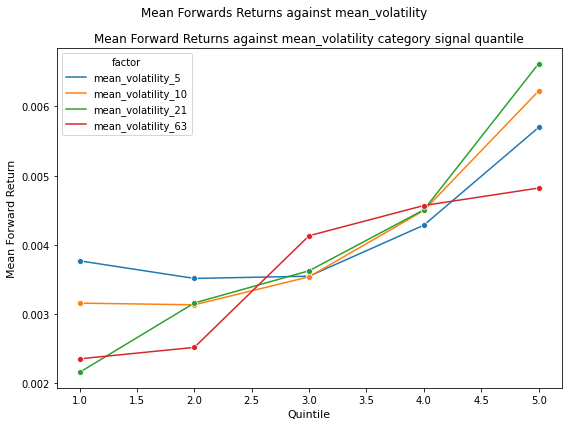

In [26]:
plot_quintiles(mv_results_quintile_dict, mv_summary_quintile_dict, "mean_volatility")

#### Momentum Spread Analysis

In [27]:
mv_spread_df

,mean_volatility_5,mean_volatility_10,mean_volatility_21,mean_volatility_63
factor,mean_volatility_5,mean_volatility_10,mean_volatility_21,mean_volatility_63
quintile,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1
mean_forward_return,0.001926,0.003062,0.004456,0.002465
std_forward_return,0.016891,0.018289,0.017627,0.015216
n_periods,1002,997,986,944
nw_t_stat,2.186061,3.003026,4.43029,2.817051
nw_p_value,0.028811,0.002673,0.000009,0.004847


**Summary**: The quintile results show a strong and largely monotonic relationship between mean volatility and future returns, with higher-volatility stocks consistently delivering higher average forward returns. The 21-day volatility signal exhibits the strongest separation, with a Q5–Q1 spread of 0.45%, the highest t-statistic (4.43) and lowest p-value (9×10⁻⁶), indicating the most robust predictive power. The 10-day and 63-day signals also perform well, generating statistically significant spreads of 0.31% and 0.25% respectively, while the 5-day signal remains weaker but still significant. The smooth upward slope across quintiles suggests the factor is capturing a genuine cross-sectional effect rather than being driven by a few outliers or extreme observations. Combined with the IC analysis, the evidence indicates that medium-term volatility (particularly 21-day volatility) provides the strongest and most reliable return signal, while very short-term volatility is more affected by noise. The highly significant p-values across all horizons provide strong statistical support that the observed return spreads are unlikely to be due to chance.

In [28]:
mv_factors = ["mean_volatility_21"]

### Correlations

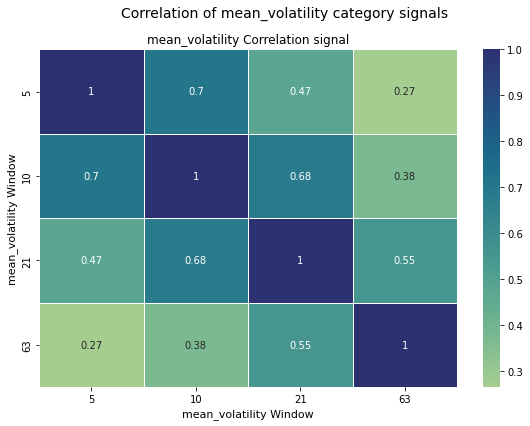

(<Figure size 576x432 with 2 Axes>,
 array([<AxesSubplot:title={'center':'mean_volatility Correlation signal'}, xlabel='mean_volatility Window', ylabel='mean_volatility Window'>],
       dtype=object))

In [29]:
mv_df = factors_df_dict["mean_volatility"]
mv_corr_df = mv_df[mv_df.columns[2:]].corr("spearman")

mv_correlation_dfs_dict = { 
    "mean_volatility": mv_corr_df
}
plot_correlation(mv_correlation_dfs_dict, "mean_volatility")

**Summary**: The strongest correlations are between nearby horizons, especially 5D–10D (0.70) and 10D–21D (0.68), meaning adjacent volatility windows capture similar information. The 63D signal is less correlated with short-term volatility, especially 5D–63D (0.27), so it captures a slower-moving, longer-term volatility regime. This supports using 21D as the main signal, because it balances short-term responsiveness with smoother information. It also suggests combining all windows may add some diversification, but 5D and 10D may be partly overlapping.

### Summary

Overall, the results support using 10D, 21D and 63D mean volatility together. The 21D signal is the strongest standalone factor, with the best IC, IC IR, quintile spread and p-value, but 10D and 63D are also statistically significant and capture different volatility horizons. The correlation matrix shows they overlap but are not redundant, especially 63D, which reflects slower regime effects. The 5D signal should likely be dropped because it is noisier, weaker, and not significant in the IC test. So the best approach is to keep 10D + 21D + 63D as complementary volatility features or combine them into one composite volatility score.

In [30]:
mv_factors = ["mean_volatility_10", "mean_volatility_21", "mean_volatility_63"]

## Microstructure

### Information Coefficient

In [31]:
microstructure_results_ic_dict, microstructure_summary_ic_df = results_ic_dict["microstructure"], summary_ic_dict["microstructure"]

#### A plot of the summary bar plot of `Microstructure` category signals

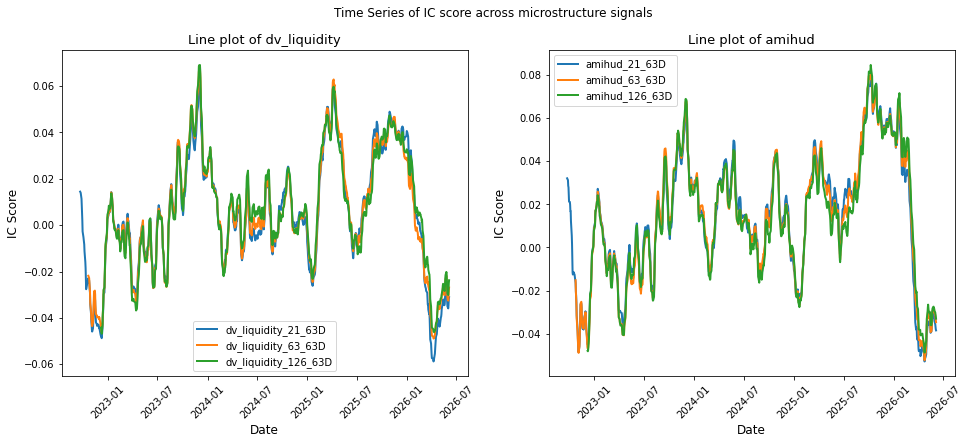

In [32]:
plot_ic_timeseries(microstructure_results_ic_dict, "microstructure")

#### A plot of the summary bar plot of `Microstructure` category signals

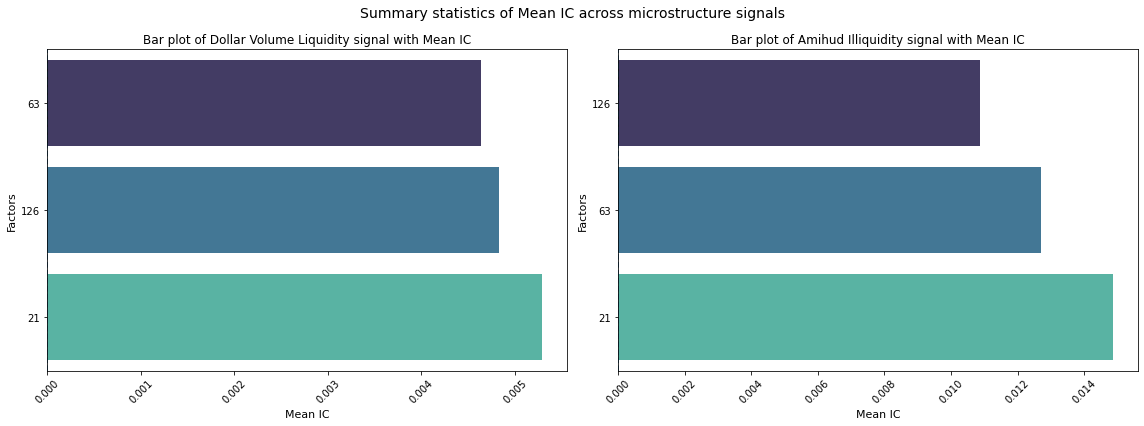

In [33]:
microstructure_name_dict = { 
    "dv_liquidity": "Dollar Volume Liquidity", 
    "amihud": "Amihud Illiquidity"
}

plot_microstructure_summary_ic_df = summary_plot_final_df(microstructure_summary_ic_df)

plot_ic_summary_bar(microstructure_results_ic_dict, plot_microstructure_summary_ic_df, microstructure_name_dict, "microstructure", metric="mean_ic")

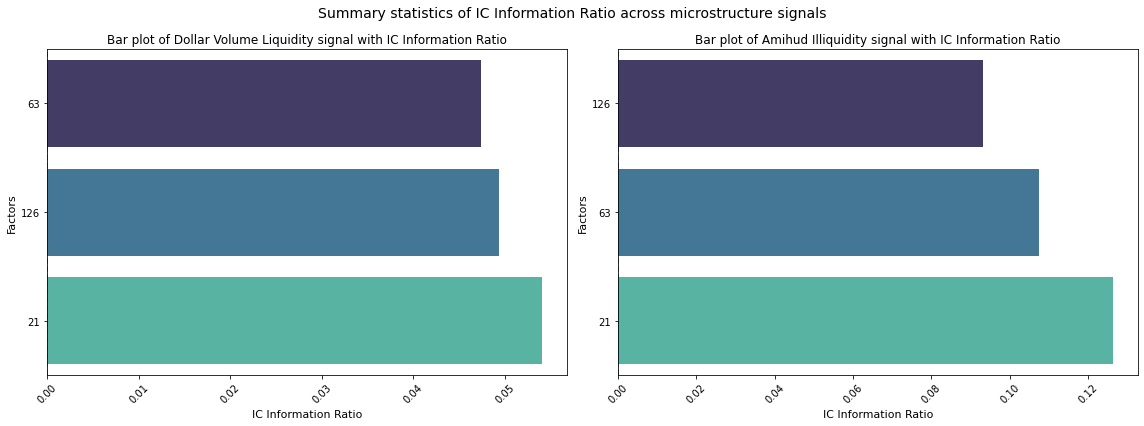

In [34]:
plot_ic_summary_bar(
    microstructure_results_ic_dict, 
    plot_microstructure_summary_ic_df,
    microstructure_name_dict,
    "microstructure", 
    metric="ic_ir"
)

In [35]:
microstructure_summary_ic_df

,Factors,mean_ic,std_ic,ic_ir,positive_ic_rate,nw_t_stat,nw_p_value,n_periods,fdr_p_value,significant_5pct
0,dv_liquidity_21,0.005294,0.097905,0.054070,0.520040,0.952091,0.341051,998.0,0.408253,False
1,dv_liquidity_63,0.004635,0.097865,0.047359,0.525077,0.826973,0.408253,977.0,0.408253,False
2,dv_liquidity_126,0.004831,0.098002,0.049293,0.526984,0.846321,0.397374,945.0,0.408253,False
3,amihud_21,0.014862,0.117632,0.126343,0.551655,2.202988,0.027596,997.0,0.165573,False
4,amihud_63,0.012691,0.117947,0.107600,0.553279,1.858444,0.063106,976.0,0.189318,False
5,amihud_126,0.010887,0.116960,0.093080,0.546610,1.579993,0.114109,944.0,0.228217,False


**Summary**: 

Overall, the microstructure signals exhibit weak but occasionally positive predictive power, with substantial variation across market regimes. The IC time series for both Dollar Volume Liquidity and Amihud Illiquidity show extended periods of positive performance, particularly during 2024–2025, followed by a sharp deterioration in late 2025 and early 2026, indicating sensitivity to changing market conditions. Among the tested specifications, Amihud(21D) performs best, achieving the highest Mean IC (0.0149), highest IC Information Ratio (0.126) and strongest t-statistic (2.20), while the Dollar Volume Liquidity signals generate much smaller ICs and weaker information ratios. However, none of the signals remain significant after FDR correction, suggesting the evidence for a persistent standalone effect is relatively weak. The high similarity between the different lookback windows also indicates that changing the horizon provides limited additional information. Therefore, if one microstructure signal were to be retained, Amihud(21D) appears to be the most promising specification, although further validation through quintile tests, regime analysis, and combination with other factors would be warranted.

### Quintile Test

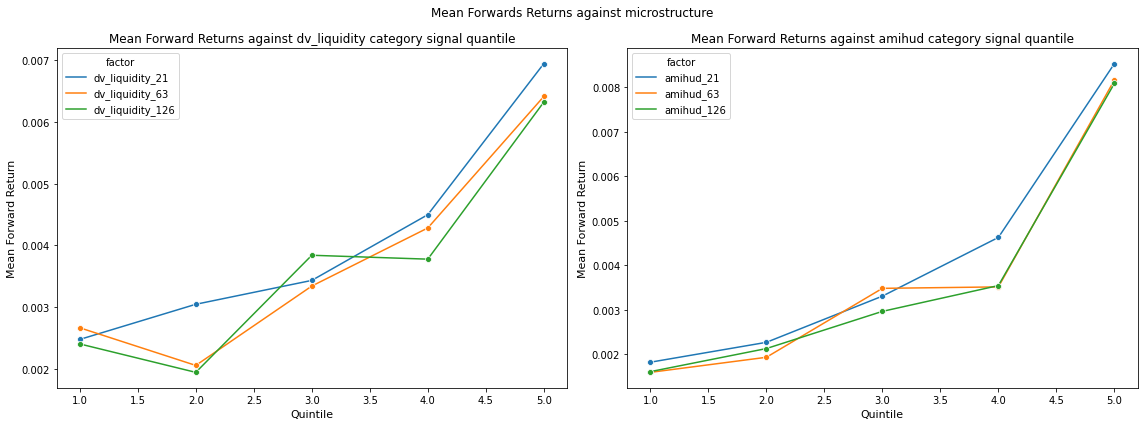

In [36]:
microstructure_results_quintile_dict, microstructure_summary_quintile_dict, mv_spread_df = (
    results_quintile_dict["microstructure"], summary_quintile_dict["microstructure"], spread_df_dict["microstructure"]
)

plot_quintiles(microstructure_results_quintile_dict, microstructure_summary_quintile_dict, "microstructure")

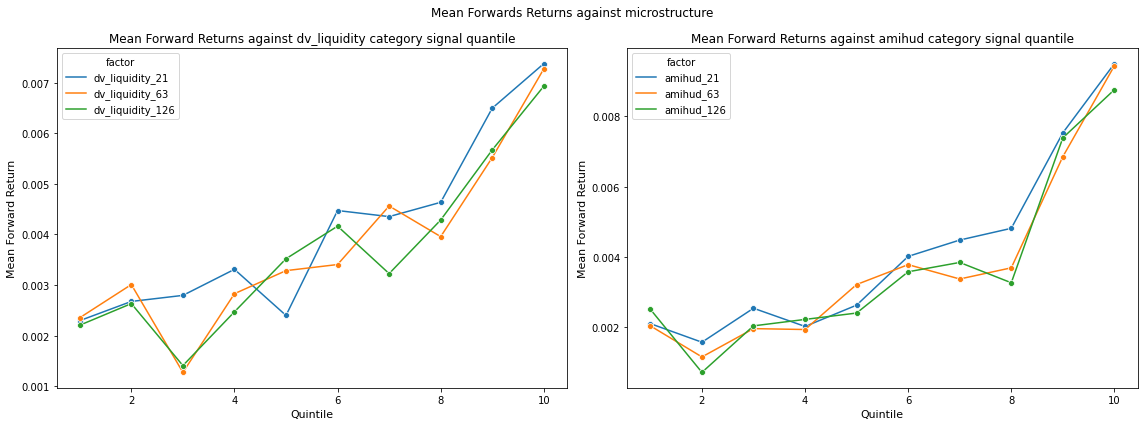

In [37]:
microstructure_results_quintile_dict_10, microstructure_summary_quintile_dict_10, microstructure_spread_df_10 = (
    Quintile(returns_df, factors_df_dict["microstructure"], 10).run_data()
)

plot_quintiles(microstructure_results_quintile_dict_10, microstructure_summary_quintile_dict_10, "microstructure")

In [38]:
mv_spread_df

,dv_liquidity_21,dv_liquidity_63,dv_liquidity_126,amihud_21,amihud_63,amihud_126
factor,dv_liquidity_21,dv_liquidity_63,dv_liquidity_126,amihud_21,amihud_63,amihud_126
quintile,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1
mean_forward_return,0.004465,0.003744,0.003915,0.006704,0.006564,0.006471
std_forward_return,0.014755,0.014425,0.014756,0.018554,0.018986,0.01933
n_periods,998,977,945,997,976,944
nw_t_stat,5.180038,4.422488,4.4084,6.136877,5.82407,5.543475
nw_p_value,0.0,0.00001,0.00001,0.0,0.0,0.0


In [39]:
microstructure_spread_df_10

,dv_liquidity_21,dv_liquidity_63,dv_liquidity_126,amihud_21,amihud_63,amihud_126
factor,dv_liquidity_21,dv_liquidity_63,dv_liquidity_126,amihud_21,amihud_63,amihud_126
quintile,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1
mean_forward_return,0.005082,0.004922,0.004726,0.007409,0.00741,0.006258
std_forward_return,0.020216,0.020687,0.021312,0.023126,0.023251,0.02184
n_periods,998,977,945,997,976,944
nw_t_stat,4.359092,4.05666,3.736496,5.447332,5.382391,4.793395
nw_p_value,0.000013,0.00005,0.000187,0.0,0.0,0.000002


**Summary**: While the IC tests suggested weak predictive power and FDR-adjusted insignificance, the portfolio sorts reveal a clear and economically meaningful illiquidity premium. Both microstructure factors produce statistically significant long-short spreads, but Amihud Illiquidity is clearly superior, generating roughly 50–80% larger spreads than Dollar Volume Liquidity and exhibiting cleaner monotonic behaviour across quantiles. The differences between 21D, 63D and 126D are relatively small, suggesting the signal is robust across horizons.

### Correlations

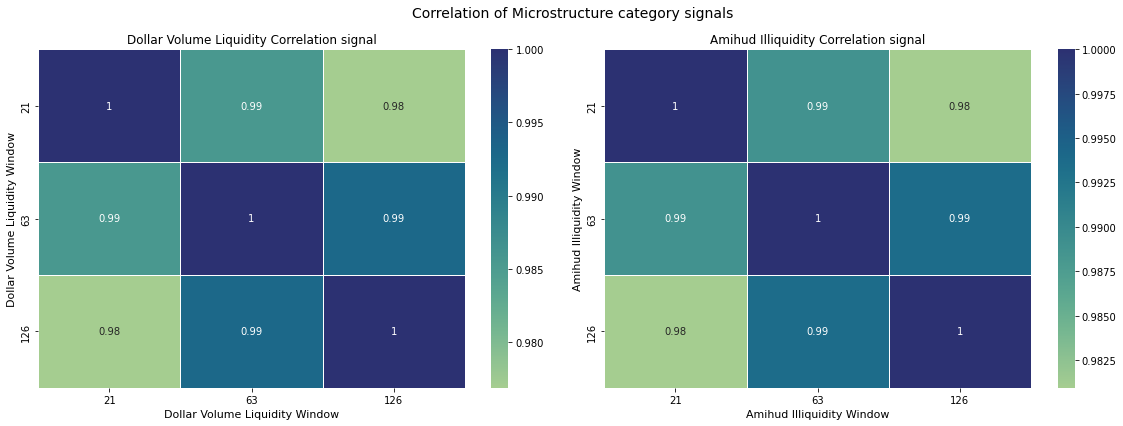

(<Figure size 1152x432 with 4 Axes>,
 array([<AxesSubplot:title={'center':'Dollar Volume Liquidity Correlation signal'}, xlabel='Dollar Volume Liquidity Window', ylabel='Dollar Volume Liquidity Window'>,
        <AxesSubplot:title={'center':'Amihud Illiquidity Correlation signal'}, xlabel='Amihud Illiquidity Window', ylabel='Amihud Illiquidity Window'>],
       dtype=object))

In [40]:
microstructure_df = factors_df_dict["microstructure"]

microstructure_df_factors = microstructure_df.columns[2:]
dv_df_correlation = microstructure_df[[col for col in microstructure_df_factors if col.startswith("dv_liquidity")]].corr("spearman")
amihud_df_correlation = microstructure_df[[col for col in microstructure_df_factors if col.startswith("amihud")]].corr("spearman")

correlation_dfs_dict = {
    "Dollar Volume Liquidity": dv_df_correlation,
    "Amihud Illiquidity": amihud_df_correlation
}

plot_correlation(correlation_dfs_dict, "Microstructure")

**Summary**: The 21D, 63D and 126D microstructure windows are almost perfectly correlated, so they are highly redundant and one horizon is likely enough. Next, we should check the correlation between dv_liquidity_21 and amihud_21 to see whether they are capturing the same liquidity effect. If the correlation is very high, keep Amihud(21D) only; if it is moderate, both may add complementary information.

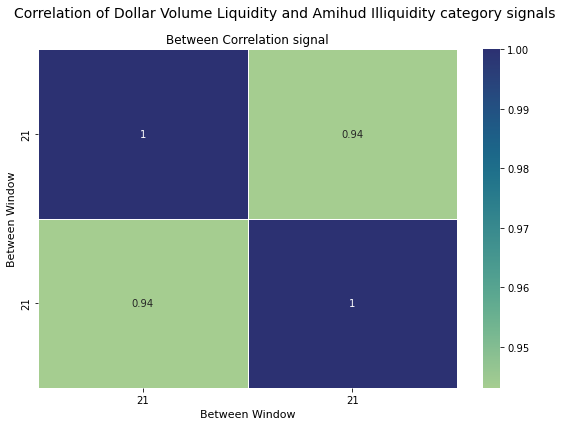

(<Figure size 576x432 with 2 Axes>,
 array([<AxesSubplot:title={'center':'Between Correlation signal'}, xlabel='Between Window', ylabel='Between Window'>],
       dtype=object))

In [41]:
### Correlation between categories

microstructure_valid_factors = ["dv_liquidity_21", "amihud_21"]

microstructure_between_correlation = microstructure_df[microstructure_valid_factors].corr("spearman")

microstructure_between_correlation_dfs_dict = {
    "Between": microstructure_between_correlation,
}

plot_correlation(microstructure_between_correlation_dfs_dict, "Dollar Volume Liquidity and Amihud Illiquidity")

We can see that under the rolling window period of 21, Amihud and Dollar Volume is highly correlated with $0.94$. Noting the previous results we do not have to include one of the two signal categories

### Summary


Overall, the microstructure results suggest that Amihud Illiquidity should be retained as the primary microstructure factor, while Dollar Volume Liquidity is optional and likely redundant. Although the IC analysis is relatively weak, the quintile tests show a clear and highly significant illiquidity premium, with Amihud producing larger Q5–Q1 and Q10–Q1 spreads, stronger t-statistics, and cleaner monotonic behaviour across quantiles. The correlation analysis shows that the 21D, 63D and 126D versions are almost perfectly correlated (0.98–0.99), meaning there is little benefit in keeping all horizons. Therefore, Amihud(21D) is the preferred specification because it delivers the highest Mean IC, highest IC Information Ratio, strongest quintile performance, and is likely to be more responsive to changing market conditions than longer windows.

In [80]:
microstructure_factors = ["amihud_21"]

## Momentum

### Information Coefficient

In [42]:
momentum_results_ic_dict, momentum_summary_ic_df = results_ic_dict["momentum"], summary_ic_dict["momentum"]

#### A plot of the time series plot of `Momentum` category signals

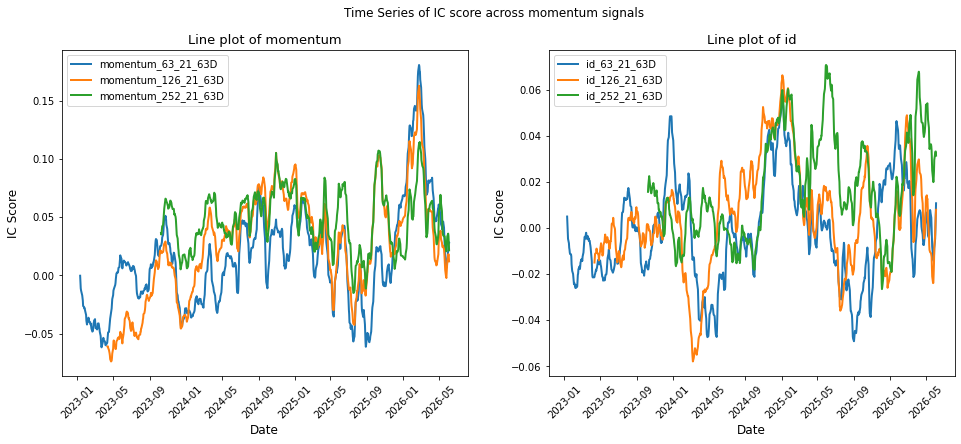

In [43]:
plot_ic_timeseries(momentum_results_ic_dict, "momentum")

#### A plot of the summary bar plot of `Momentum` category signals

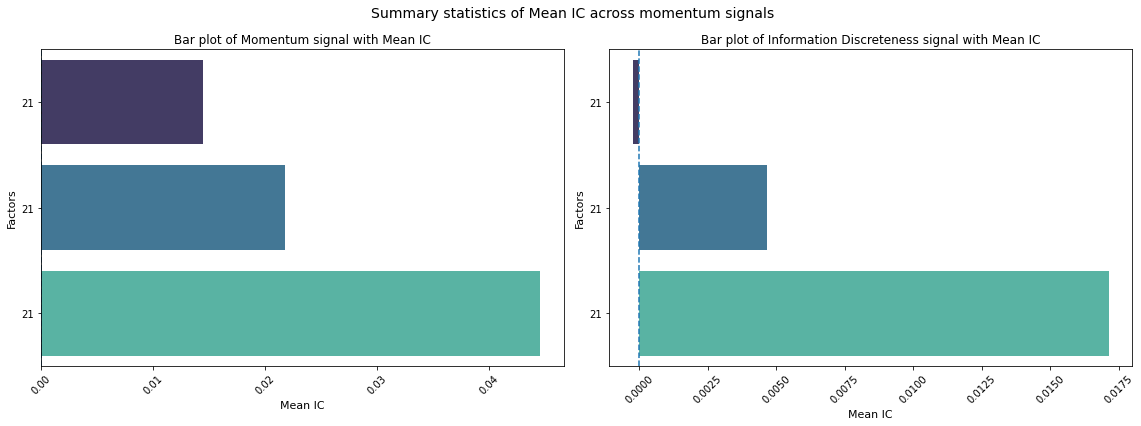

In [44]:
momentum_name_dict = { 
    "momentum": "Momentum", 
    "id": "Information Discreteness"
}

plot_momentum_summary_ic_df = summary_plot_final_df(momentum_summary_ic_df)

plot_ic_summary_bar(momentum_results_ic_dict, plot_momentum_summary_ic_df, momentum_name_dict, "momentum", metric="mean_ic")

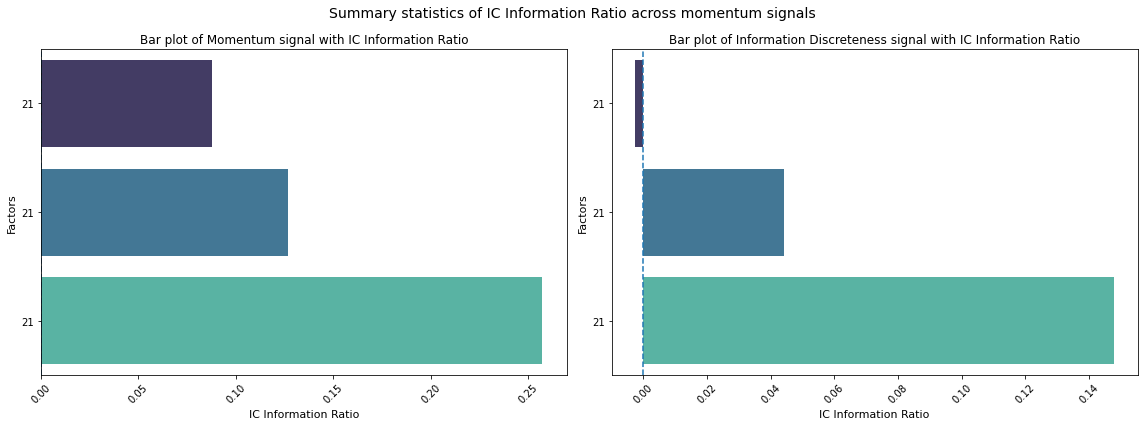

In [45]:
plot_ic_summary_bar(momentum_results_ic_dict, plot_momentum_summary_ic_df, momentum_name_dict, "momentum", metric="ic_ir")

In [46]:
momentum_summary_ic_df

,Factors,mean_ic,std_ic,ic_ir,positive_ic_rate,nw_t_stat,nw_p_value,n_periods,fdr_p_value,significant_5pct
0,momentum_63_21,0.014494,0.165456,0.087603,0.531961,1.477361,0.139579,923.0,0.209368,False
1,momentum_126_21,0.021786,0.171714,0.126876,0.562791,2.072611,0.038209,860.0,0.076417,False
2,momentum_252_21,0.044546,0.173242,0.257132,0.637602,3.949496,0.000078,734.0,0.000470,True
3,id_63_21,-0.000241,0.099071,-0.002434,0.502709,-0.042047,0.966461,923.0,0.966461,False
4,id_126_21,0.004651,0.105449,0.044105,0.512791,0.710173,0.477597,860.0,0.573116,False
5,id_252_21,0.017138,0.116036,0.147695,0.554496,2.274269,0.022950,734.0,0.068849,False


**Summary**: The momentum results show that longer-horizon momentum is clearly stronger, with momentum_252_21 producing the highest Mean IC, IC IR, positive IC rate, t-statistic and FDR-adjusted significance. The time-series plot shows some negative IC periods, especially around early 2023 and mid-2025, but the longer-horizon momentum signal recovers well and spends more time in positive territory. The shorter momentum windows, especially 63–21, are weaker and more unstable. For information discreteness, the results are much less convincing, with id_63_21 having a slightly negative Mean IC and several periods where the IC stays below zero. Although id_252_21 has some positive signal, it does not remain significant after FDR correction. Overall, momentum_252_21 should be retained as the main momentum factor, while ID should be treated as secondary or experimental rather than a core signal.

### Quintile Test

**An plot of Long-Short of 5 Quintile**

In [47]:
momentum_results_quintile_dict, momentum_summary_quintile_dict, momentum_spread_df = (
    results_quintile_dict["momentum"], summary_quintile_dict["momentum"], spread_df_dict["momentum"]
)

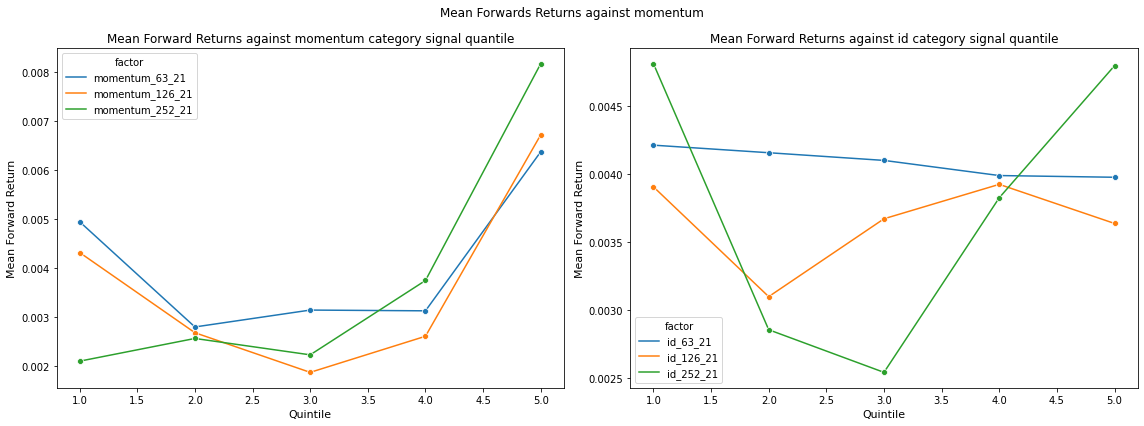

In [48]:
plot_quintiles(momentum_results_quintile_dict, momentum_summary_quintile_dict, "momentum")

**A plot of Long-Short of 10 Quintile**

In [49]:
momentum_quintile_10_dict, momentum_summary_quintile_10_df, momentum_spread_10_df = Quintile(returns_df, factors_df_dict["momentum"], 10).run_data()

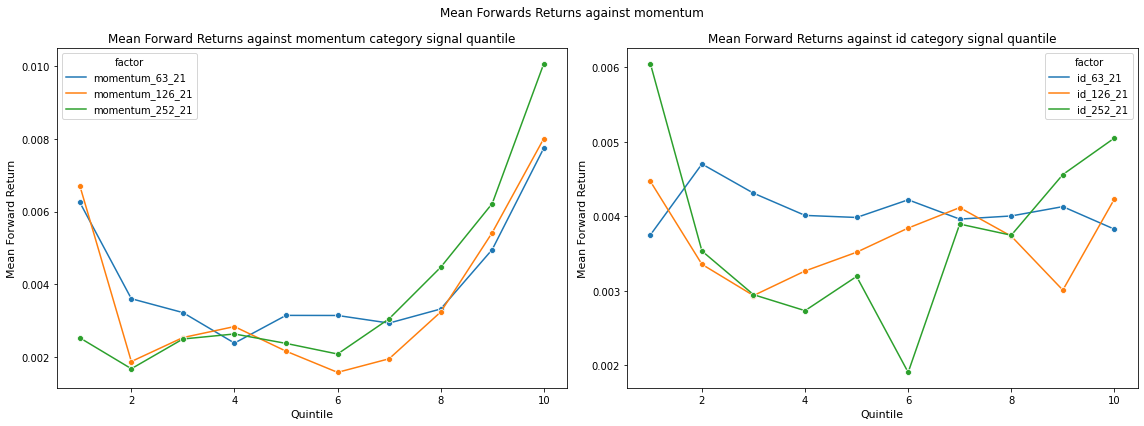

In [50]:
plot_quintiles(momentum_quintile_10_dict, momentum_summary_quintile_10_df, "momentum")

#### Momentum Spread Analysis

**An analysis of Long-Short of 5 Quintile**

In [51]:
momentum_spread_df

,momentum_63_21,momentum_126_21,momentum_252_21,id_63_21,id_126_21,id_252_21
factor,momentum_63_21,momentum_126_21,momentum_252_21,id_63_21,id_126_21,id_252_21
quintile,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1
mean_forward_return,0.001426,0.002401,0.006066,-0.000236,-0.00027,-0.000015
std_forward_return,0.026563,0.028403,0.028902,0.015063,0.016958,0.0173
n_periods,923,860,734,923,860,734
nw_t_stat,0.911758,1.378837,3.199894,-0.271901,-0.254496,-0.013282
nw_p_value,0.361896,0.167945,0.001375,0.785698,0.799113,0.989403


#### An analysis of Long-Short of 10 Quintile

In [52]:
momentum_spread_10_df

,momentum_63_21,momentum_126_21,momentum_252_21,id_63_21,id_126_21,id_252_21
factor,momentum_63_21,momentum_126_21,momentum_252_21,id_63_21,id_126_21,id_252_21
quintile,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1
mean_forward_return,0.001488,0.001291,0.007531,0.000077,-0.000237,-0.000998
std_forward_return,0.036836,0.037325,0.03884,0.02084,0.023033,0.02445
n_periods,923,860,734,923,860,734
nw_t_stat,0.690121,0.568736,2.933578,0.066054,-0.166127,-0.608465
nw_p_value,0.490118,0.569535,0.003351,0.947335,0.868057,0.542879


**Summary**: The 10-quintile analysis is actually quite informative because it confirms what the 5-quintile results were hinting at. For momentum_252_21, the relationship becomes much clearer: returns are lowest in the middle quintiles and increase sharply in the highest deciles, producing a strong long-short spread (Q10-Q1 = 0.75%, p = 0.003). The 63–21 and 126–21 momentum signals also exhibit a U-shaped pattern, but the separation between the extreme deciles is much smaller and statistically insignificant. For the ID signals, the U-shape is even more pronounced, with both the lowest and highest deciles outperforming the middle deciles, which explains why the IC and long-short results are weak despite some positive average IC values. This suggests that information discreteness is not a monotonic factor, and a simple long-high/short-low portfolio may not be the correct way to monetise it. Overall, the decile analysis strengthens the case for momentum_252_21 as the only robust momentum signal, while also revealing that the ID factors may require a different portfolio construction if they are to be used at all.

### Correlation

In [53]:
momentum_df = factors_df_dict["momentum"]
momentum_df_factors = momentum_df.columns[2:]
mom_df_correlation = momentum_df[[col for col in momentum_df_factors if col.startswith("momentum")]].corr("spearman")
id_df_correlation = momentum_df[[col for col in momentum_df_factors if col.startswith("id")]].corr("spearman")

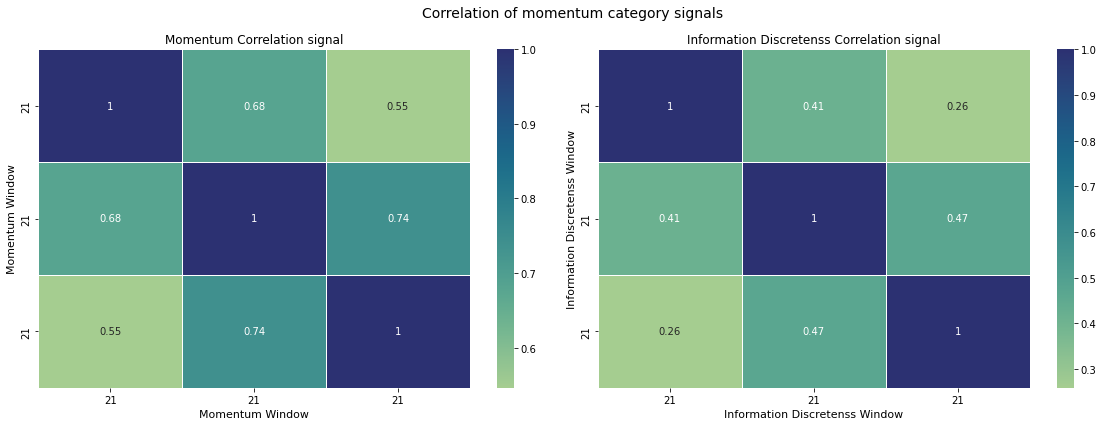

(<Figure size 1152x432 with 4 Axes>,
 array([<AxesSubplot:title={'center':'Momentum Correlation signal'}, xlabel='Momentum Window', ylabel='Momentum Window'>,
        <AxesSubplot:title={'center':'Information Discretenss Correlation signal'}, xlabel='Information Discretenss Window', ylabel='Information Discretenss Window'>],
       dtype=object))

In [54]:
correlation_dfs_dict = {
    "Momentum": mom_df_correlation, 
    "Information Discretenss": id_df_correlation
}

plot_correlation(correlation_dfs_dict, "momentum")

In [55]:
momentum_df["momentum_252_21"].corr( momentum_df["id_252_21"], method="spearman")

0.29605247639489096

The Spearman correlation between momentum_252_21 and id_252_21 is 0.296, indicating a low-to-moderate positive relationship. This suggests the two signals rank stocks somewhat similarly, but there is still meaningful difference in the information they capture.

### Summary

Overall, the momentum results are strongest for momentum_252_21, which has the best IC, IC IR, positive IC rate, quintile spread and statistical significance. The shorter momentum windows are weaker and less stable, while the ID signals show more negative IC periods and less consistent predictive power. The quintile plots suggest momentum has a clearer payoff at the high-ranked end, whereas ID appears more U-shaped and harder to use directionally. The Spearman correlation between momentum_252_21 and id_252_21 is only 0.296, suggesting modest overlap but not redundancy.

In [56]:
momentum_factors = ["momentum_252_21"]

## Momentum Liquidity

### Information Coefficient

In [57]:
ml_results_ic_dict, ml_summary_ic_df = results_ic_dict["momentum_liquidity"], summary_ic_dict["momentum_liquidity"]

#### A plot of the time series of `Momentum Liquidity` category signals

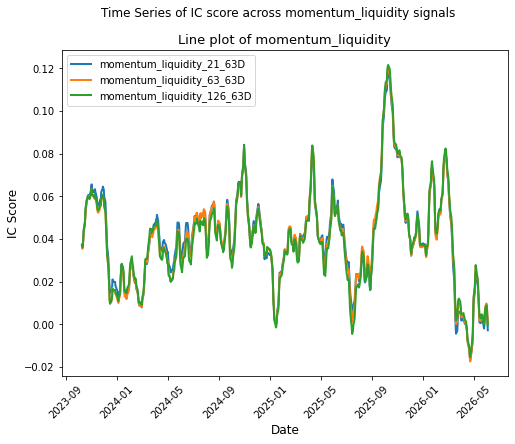

In [58]:
plot_ic_timeseries(ml_results_ic_dict, "momentum_liquidity")

#### A plot of the summary bar plot of `Momentum Liquidity` category signals

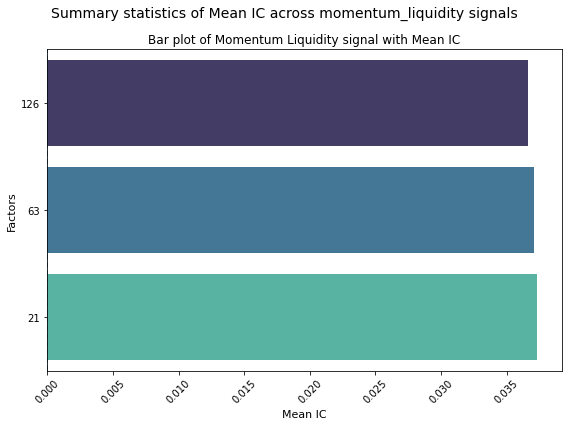

In [59]:
ml_name_dict = { 
    "momentum_liquidity": "Momentum Liquidity"
}

plot_ml_summary_ic_df = summary_plot_final_df(ml_summary_ic_df)

plot_ic_summary_bar(
    ml_results_ic_dict, 
    plot_ml_summary_ic_df,
    ml_name_dict,
    "momentum_liquidity",
    metric="mean_ic"
)

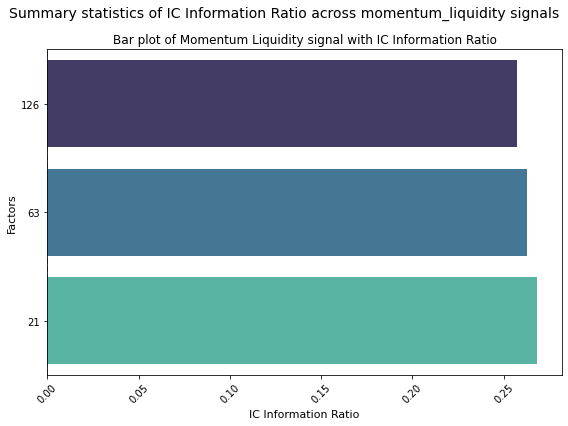

In [60]:
plot_ic_summary_bar(
    ml_results_ic_dict, 
    plot_ml_summary_ic_df,
    ml_name_dict,
    "momentum_liquidity",
    metric="ic_ir"
)

In [61]:
ml_summary_ic_df

,Factors,mean_ic,std_ic,ic_ir,positive_ic_rate,nw_t_stat,nw_p_value,n_periods,fdr_p_value,significant_5pct
0,momentum_liquidity_21,0.037321,0.139096,0.268314,0.611717,4.154256,0.000033,734.0,0.000067,True
1,momentum_liquidity_63,0.037102,0.141080,0.262987,0.615804,4.083089,0.000044,734.0,0.000067,True
2,momentum_liquidity_126,0.036599,0.142334,0.257133,0.613079,3.978907,0.000069,734.0,0.000069,True


**Summary**: The momentum-liquidity signals are very close together across all windows, with 21D, 63D and 126D producing nearly identical IC time-series behaviour. All three have strong Mean ICs around 0.036–0.037, IC IR around 0.26, positive IC rates above 61%, and highly significant FDR-adjusted p-values. The 21D version is marginally strongest, but the differences are very small, so the key takeaway is that the signal is robust across horizons rather than dependent on one specific window.

### Quintile Test

**An plot of Long-Short of 5 Quintile**

In [62]:
ml_results_quintile_dict, ml_summary_quintile_dict, ml_spread_df = (
    results_quintile_dict["momentum_liquidity"], summary_quintile_dict["momentum_liquidity"], spread_df_dict["momentum_liquidity"]
)

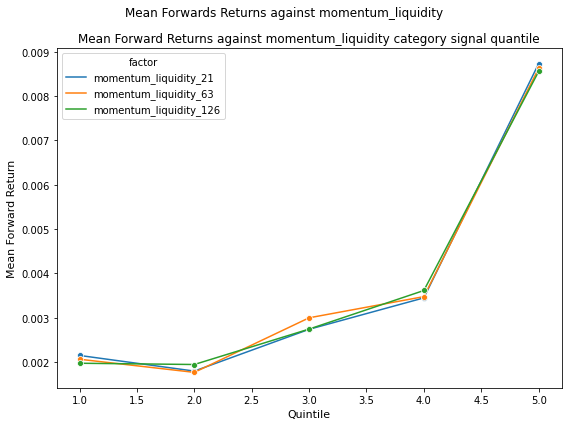

In [63]:
plot_quintiles(ml_results_quintile_dict, ml_summary_quintile_dict, "momentum_liquidity")

#### Momentum Liquidity Spread Analysis

In [64]:
ml_spread_df

,momentum_liquidity_21,momentum_liquidity_63,momentum_liquidity_126
factor,momentum_liquidity_21,momentum_liquidity_63,momentum_liquidity_126
quintile,Q5-Q1,Q5-Q1,Q5-Q1
mean_forward_return,0.006586,0.006564,0.006585
std_forward_return,0.023823,0.02493,0.025137
n_periods,734,734,734
nw_t_stat,4.215012,4.037889,3.997257
nw_p_value,0.000025,0.000054,0.000064


**Summary**: The quintile results are very strong and nearly identical across the 21D, 63D and 126D momentum-liquidity windows. All three show a clear upward pattern, with Q5 producing much higher forward returns than Q1 and Q5–Q1 spreads around 0.66%. The Newey-West p-values are extremely low, confirming the long-short spreads are statistically significant. This suggests the momentum-liquidity effect is robust across windows rather than dependent on one specific lookback.

### Correlation

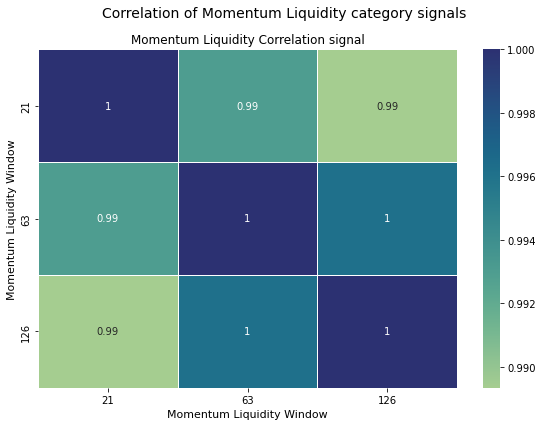

(<Figure size 576x432 with 2 Axes>,
 array([<AxesSubplot:title={'center':'Momentum Liquidity Correlation signal'}, xlabel='Momentum Liquidity Window', ylabel='Momentum Liquidity Window'>],
       dtype=object))

In [65]:
ml_df = factors_df_dict["momentum_liquidity"]

ml_df_factors = ml_df.columns[2:]
ml_df_correlation = ml_df[ml_df_factors].corr("spearman")

correlation_dfs_dict = {
    "Momentum Liquidity": ml_df_correlation,
}

plot_correlation(correlation_dfs_dict, "Momentum Liquidity")

The momentum-liquidity windows are almost perfectly correlated (0.99–1.00), so they are highly redundant and a representative window can be kept while removing the others.

### Summary

Overall, the momentum-liquidity factor appears highly robust, with all three windows producing strong Mean ICs (~0.036–0.037), IC Information Ratios (~0.26), positive IC rates above 61%, and highly significant p-values after FDR correction. The IC time series shows consistently positive predictive power across most of the sample, while the quintile analysis exhibits a clear monotonic relationship and statistically significant Q5–Q1 spreads of approximately 0.66% across all horizons. The correlation analysis shows that the 21D, 63D and 126D versions are almost perfectly correlated (0.99–1.00), indicating that they capture essentially the same information. Given the near-identical performance, the 21D window is preferred as it delivers the strongest IC, highest IC IR, largest quintile spread, and is likely to be more responsive to changing market conditions. Therefore, momentum_liquidity_21 can be retained as the representative signal while the longer horizons can be removed with minimal information loss.

In [66]:
momentum_liquidity_factors = ["momentum_liquidity_21"]

## Reversal

### Information Coefficient

In [67]:
reversal_results_ic_dict, reversal_summary_ic_df = results_ic_dict["reversal"], summary_ic_dict["reversal"]

#### A plot of the time series of `Reversal` category signals

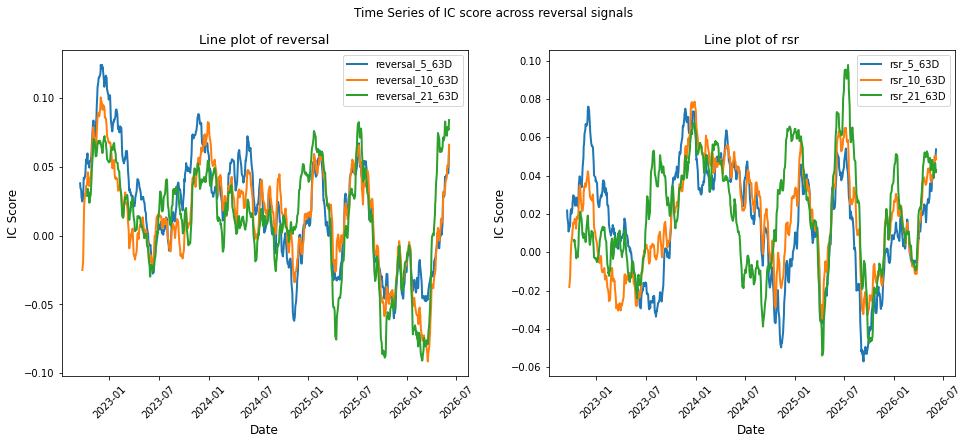

In [68]:
plot_ic_timeseries(reversal_results_ic_dict, "reversal")

#### A plot of the summary bar plot of `Reversal` category signals

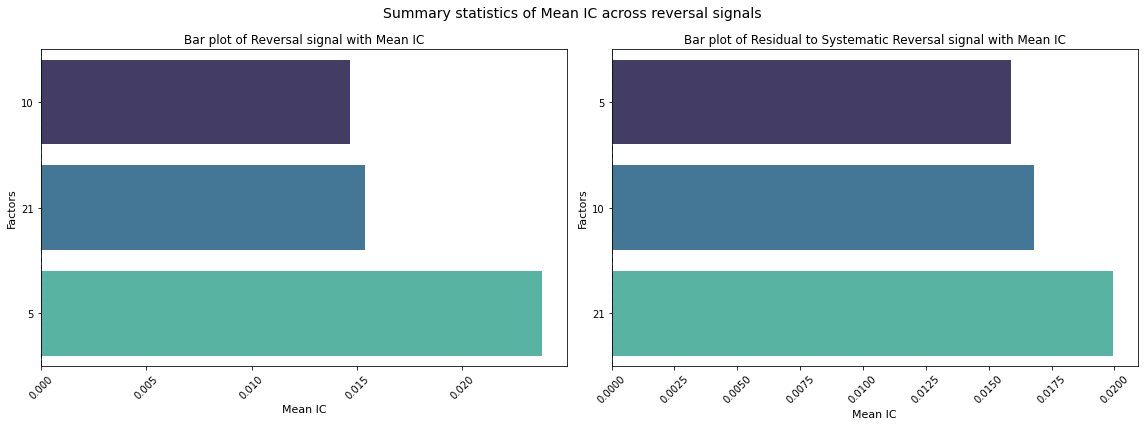

In [69]:
name_dict = {
    "reversal": "Reversal", 
    "rsr": "Residual to Systematic Reversal"
}

plot_reversal_summary_ic_df = summary_plot_final_df(reversal_summary_ic_df)

plot_ic_summary_bar(reversal_results_ic_dict, plot_reversal_summary_ic_df, name_dict, "reversal", metric="mean_ic")

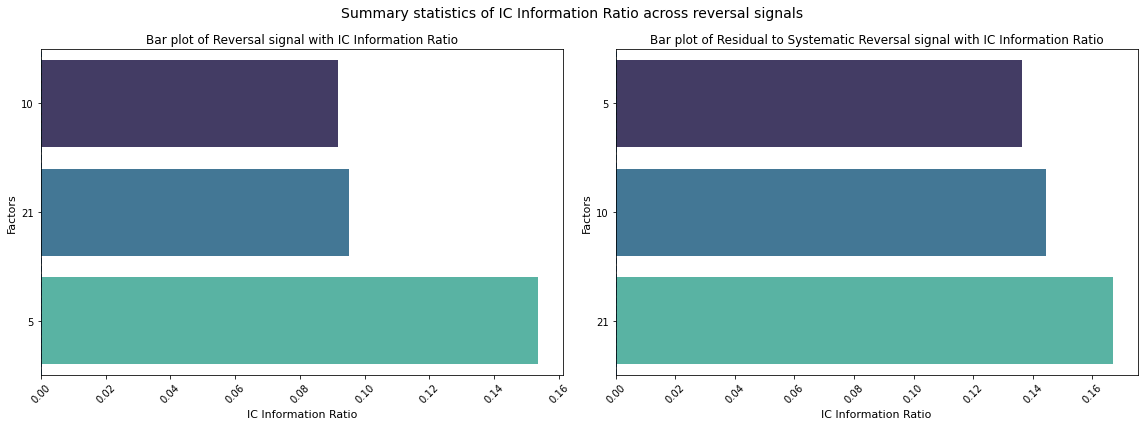

In [70]:
plot_ic_summary_bar(reversal_results_ic_dict, plot_reversal_summary_ic_df, name_dict, "reversal", metric="ic_ir")

In [71]:
reversal_summary_ic_df

,Factors,mean_ic,std_ic,ic_ir,positive_ic_rate,nw_t_stat,nw_p_value,n_periods,fdr_p_value,significant_5pct
0,reversal_5,0.023775,0.154832,0.153553,0.567864,2.922585,0.003471,1002.0,0.010414,True
1,reversal_10,0.014680,0.159929,0.091791,0.517553,1.701559,0.088838,997.0,0.095309,False
2,reversal_21,0.015380,0.161706,0.095111,0.530426,1.668032,0.095309,986.0,0.095309,False
3,rsr_5,0.015893,0.116616,0.136280,0.546906,2.607053,0.009133,1002.0,0.013699,True
4,rsr_10,0.016805,0.116223,0.144597,0.566700,2.680704,0.007347,997.0,0.013699,True
5,rsr_21,0.019927,0.119392,0.166901,0.565923,2.959531,0.003081,986.0,0.010414,True


**Summary**: The reversal signals show positive predictive power overall, but the effect is strongest for the 5-day horizon, which achieves the highest Mean IC (0.0238), highest IC Information Ratio (0.154), and remains statistically significant after FDR correction. The IC time series indicates that reversal performance is highly regime-dependent, with periods of strong positive predictive power interspersed with extended drawdowns and negative ICs, particularly during 2025–2026. In contrast, the Residual-to-Systematic Reversal (RSR) signals are more consistent across horizons, with all three windows remaining significant after FDR correction and showing steadily improving performance as the lookback window increases. The RSR(21D) specification stands out, delivering the highest Mean IC (0.0199), highest IC Information Ratio (0.167), strongest t-statistic (2.96), and the most stable performance profile. While traditional reversal appears stronger at very short horizons, RSR provides a cleaner and more robust signal by isolating stock-specific reversals from broader market and industry effects. Overall, both families appear useful, but the evidence suggests that RSR is the more stable and statistically robust reversal framework, whereas standard reversal derives most of its strength from the shortest lookback horizon.

### Quintile Test

In [72]:
reversal_results_quintile_dict, reversal_summary_quintile_dict, reversal_spread_df = (
    results_quintile_dict["reversal"], summary_quintile_dict["reversal"], spread_df_dict["reversal"]
)

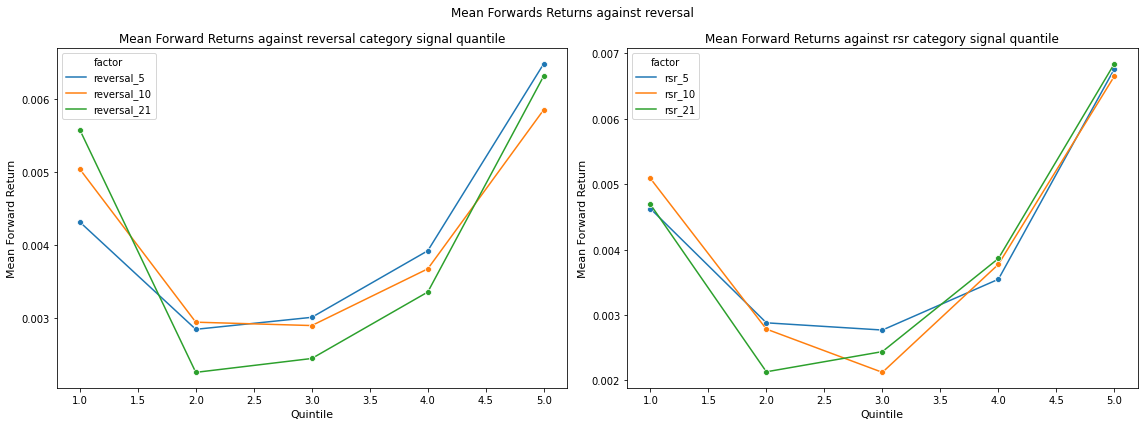

In [73]:
plot_quintiles(reversal_results_quintile_dict, reversal_summary_quintile_dict, "reversal")

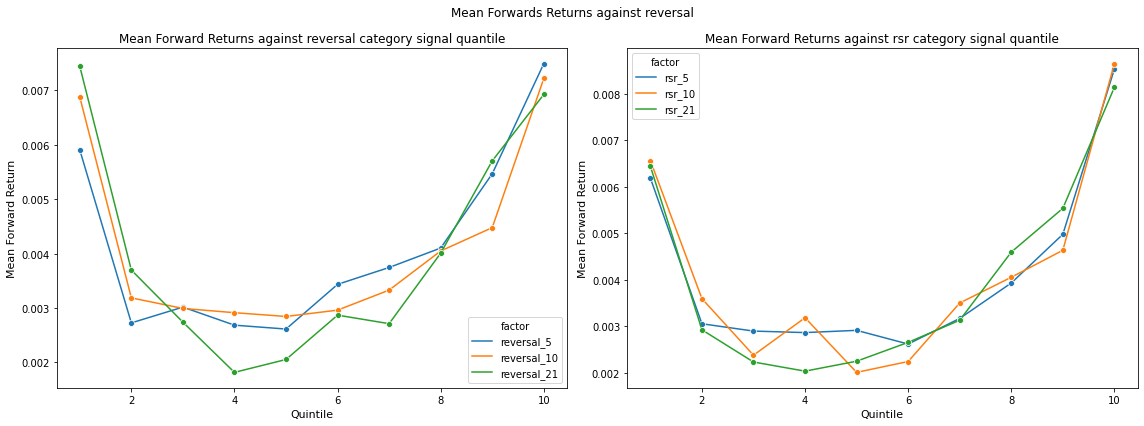

In [74]:
reversal_quintile_10_dict, reversal_summary_quintile_10_df, reversal_spread_10_df = Quintile(returns_df, factors_df_dict["reversal"], 10).run_data()

plot_quintiles(reversal_quintile_10_dict, reversal_summary_quintile_10_df, "reversal")

#### Reversal Spread Analysis

**An analysis of Long-Short of 5 Quintile**

In [75]:
reversal_spread_df

,reversal_5,reversal_10,reversal_21,rsr_5,rsr_10,rsr_21
factor,reversal_5,reversal_10,reversal_21,rsr_5,rsr_10,rsr_21
quintile,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1,Q5-Q1
mean_forward_return,0.002163,0.000812,0.000736,0.002135,0.001563,0.002151
std_forward_return,0.024113,0.025511,0.025195,0.020542,0.020322,0.020564
n_periods,1002,997,986,1002,997,986
nw_t_stat,1.743542,0.60182,0.512034,2.02366,1.45432,1.85109
nw_p_value,0.081239,0.547294,0.608627,0.043005,0.145858,0.064157


**An analysis of Long-Short of 10 Quintile**

In [76]:
reversal_spread_10_df

,reversal_5,reversal_10,reversal_21,rsr_5,rsr_10,rsr_21
factor,reversal_5,reversal_10,reversal_21,rsr_5,rsr_10,rsr_21
quintile,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1,Q10-Q1
mean_forward_return,0.001586,0.000342,-0.000518,0.002345,0.002085,0.001697
std_forward_return,0.032816,0.034781,0.035535,0.030968,0.030351,0.030963
n_periods,1002,997,986,1002,997,986
nw_t_stat,0.948466,0.185237,-0.257076,1.514107,1.302641,0.97736
nw_p_value,0.342892,0.853043,0.79712,0.129999,0.192697,0.328391


**Summary**: The reversal and RSR plots show a clear U-shaped relationship, where both low and high signal buckets outperform the middle buckets. This means the factor is not purely monotonic, so simple Q5–Q1 or Q10–Q1 long-short spreads understate the useful information. The pattern suggests reversal is capturing extreme price/residual movement behaviour rather than a clean linear ranking effect. RSR shows a similar U-shape, meaning the effect remains even after adjusting for systematic market and industry exposure. Since you are using machine learning, this is useful because ML models can capture non-linear effects where both extremes matter. Overall, reversal and RSR are worth keeping as features, but they should be treated as non-linear predictors, not simple long-high/short-low factors.

### Correlation

In [77]:
reversal_df = factors_df_dict["reversal"]
reversal_df_factors = reversal_df.columns[2:]
rev_df_correlation = reversal_df[[col for col in reversal_df_factors if col.startswith("reversal")]].corr("spearman")
rsr_df_correlation = reversal_df[[col for col in reversal_df_factors if col.startswith("rsr")]].corr("spearman")

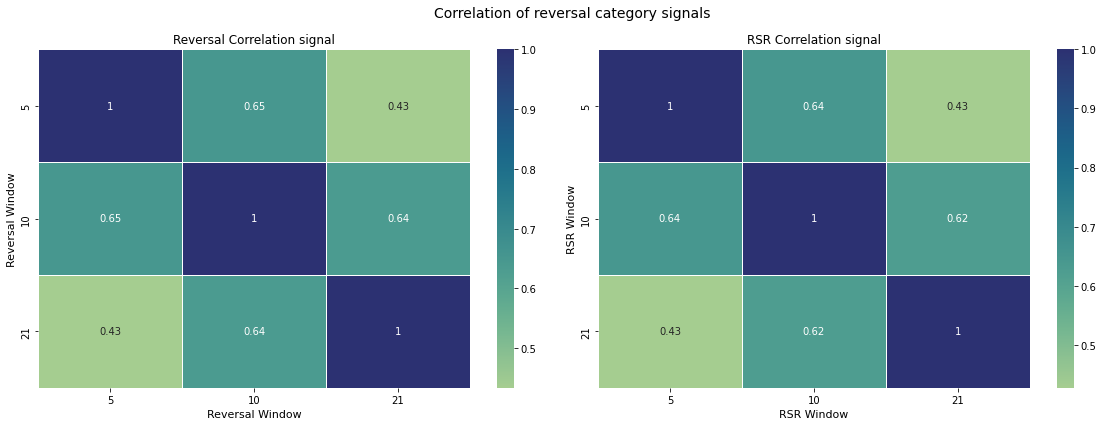

(<Figure size 1152x432 with 4 Axes>,
 array([<AxesSubplot:title={'center':'Reversal Correlation signal'}, xlabel='Reversal Window', ylabel='Reversal Window'>,
        <AxesSubplot:title={'center':'RSR Correlation signal'}, xlabel='RSR Window', ylabel='RSR Window'>],
       dtype=object))

In [78]:
correlation_dfs_dict = {
    "Reversal": rev_df_correlation, 
    "RSR": rsr_df_correlation
}

plot_correlation(correlation_dfs_dict, "reversal")

#### Summary

Overall, both the traditional reversal and RSR families show evidence of predictive power, but they differ in where that strength comes from. Traditional reversal achieves its best performance at the 5-day horizon, delivering the highest Mean IC and remaining significant after FDR correction, whereas RSR exhibits more consistent performance across horizons and improves as the lookback window increases, with RSR(21D) achieving the highest Mean IC, IC Information Ratio, and strongest statistical significance within the family. The quintile and decile analyses reveal a pronounced U-shaped relationship for both signals, indicating that predictive power is concentrated in the extreme buckets rather than following a simple monotonic ranking. Since the longer reversal horizons add little incremental value and RSR(21D) appears more robust and stable than the other RSR specifications, the preferred signals are reversal_5 and rsr_21. Given the U-shaped behaviour, these factors are best used with non-linear transformations such as squared values, absolute values, or extreme-bucket indicators so that machine learning models can exploit the information contained in both tails of the distribution.

In [79]:
reversal_factors = ["reversal_5", "rsr_21"]

## Reversal Illiquidity

In [10]:
from scripts.research.plots_2D import plot_ic_timeseries_2D,  plot_ic_summary_bar_2D

In [7]:
ri_results_ic_dict, ri_summary_ic_df = results_ic_dict["reversal_illiquidity"], summary_ic_dict["reversal_illiquidity"]

In [8]:
plot_ri_summary_ic_df = summary_plot_final_df(ri_summary_ic_df)

In [12]:
def ri_results(ri_results_ic_dict, ri_summary_ic_df): 
    ri_results_dict_ic = {
        5: {},
        10: {}, 
        21: {}
    }
    
    
    
    ri_columns = {
        5: [],
        10: [], 
        21: []
    }
    for key, df in ri_results_ic_dict.items(): 
        if key.startswith("reversal_illiquidity_(5"): 
            ri_results_dict_ic[5][key] = df
            ri_columns[5].append(key)
        elif key.startswith("reversal_illiquidity_(10"): 
            ri_results_dict_ic[10][key] = df
            ri_columns[10].append(key)
        elif key.startswith("reversal_illiquidity_(21"):
            ri_results_dict_ic[21][key] = df
            ri_columns[21].append(key)
    
    summary_results_dict_ic = {} 
    
    
    for key in ri_columns.keys(): 
        summary_results_dict_ic[key] = ri_summary_ic_df[ri_columns[key]]
    
    
    return ri_results_dict_ic, summary_results_dict_ic

In [14]:
ri_results_ic_dict_final, ri_summary_ic_df_final_dict = ri_results(ri_results_ic_dict, plot_ri_summary_ic_df)

#### A plot of the time series of `Reversal Illiquidity` category signals

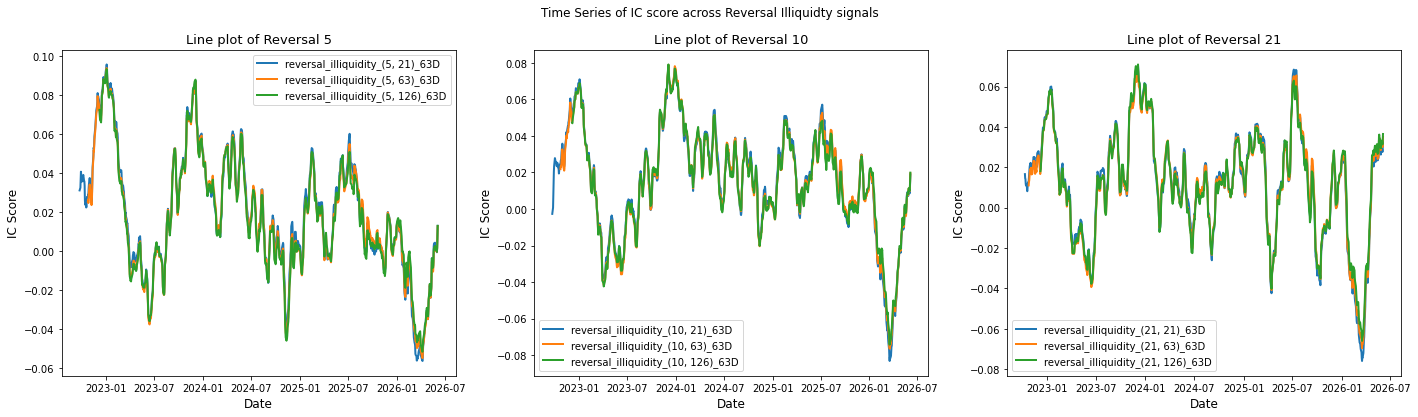

In [16]:
plot_ic_timeseries_2D(ri_results_ic_dict_final, "reversal_illiquidity")

#### A plot of the summary bar plot of `Reversal Illiquidity` category signals

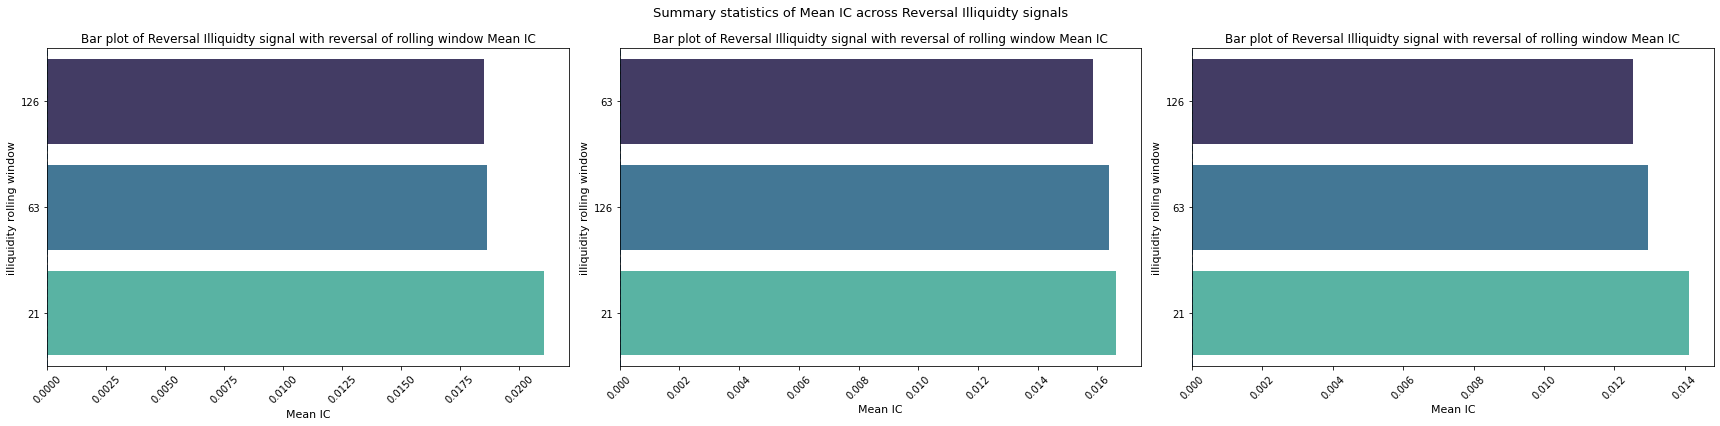

In [17]:
plot_ic_summary_bar_2D(ri_summary_ic_df_final_dict, "reversal_illiquidity", metric="mean_ic")

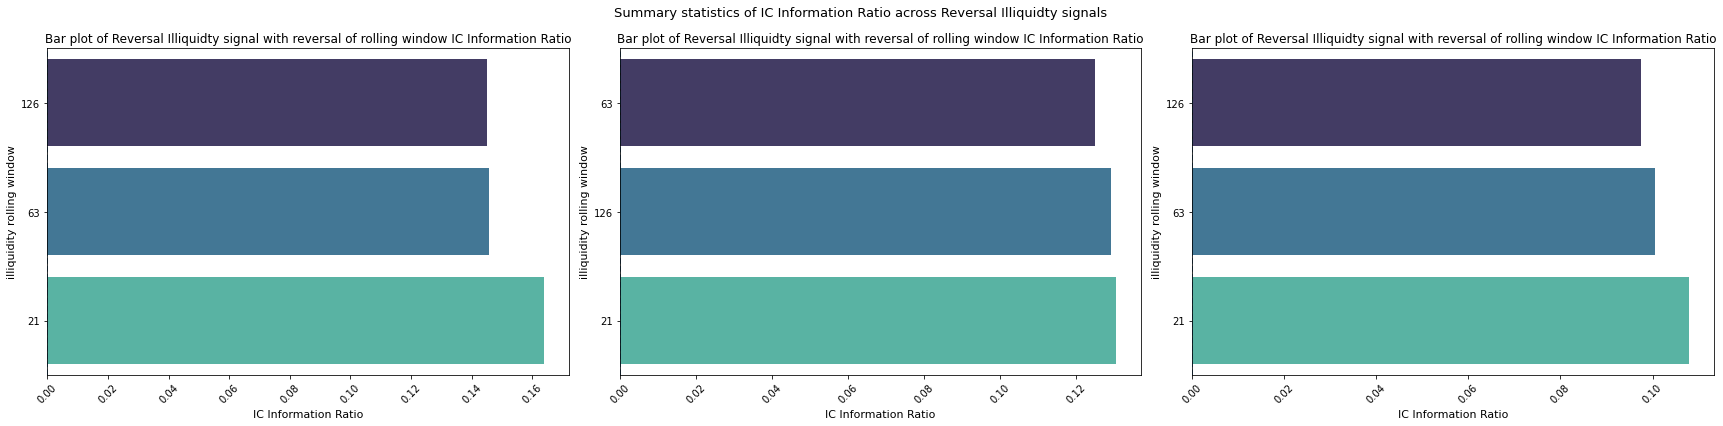

In [18]:
plot_ic_summary_bar_2D(ri_summary_ic_df_final_dict, "reversal_illiquidity", metric="ic_ir")

### Quintile Tests

In [22]:
ri_results_quintile_dict, ri_summary_quintile_dict, ri_spread_dict = (
    results_quintile_dict["reversal_illiquidity"], summary_quintile_dict["reversal_illiquidity"], spread_df_dict["reversal_illiquidity"]
)

In [52]:
def plot_quintiles(quintile_df_dict: dict, summary_dict: dict, category_name):
    category_dicts = utils.get_final_dict(quintile_df_dict, category_name)
    
    n = len(category_dicts.keys())
    print(n)
    
    if (n == 1):
        fig, axs = plt.subplots(1, 1, figsize=(8, 6))
    elif (n == 2): 
        fig, axs = plt.subplots(1, 2, figsize=(16, 6)) 
    elif (n == 3): 
        fig, axs = plt.subplots(1, 3, figsize=(24, 6)) 
    elif (n == 4): 
        fig, axs = plt.subplots(2, 2, figsize=(16, 12))       
    
    axs = np.atleast_1d(axs).ravel()
    
    fig.suptitle(f"Mean Forwards Returns against {category_name}")
    i = 0
    for category, category_signal_names in category_dicts.items(): 
        if category.startswith("reversal_illiquidity_("):
            m = re.search(r"_\((\d+)\)?$", category)
            if m:
                category = category[:m.start()] + f"_window_{m.group(1)}"

        axs[i].set_title(f"Mean Forward Returns against {category} category signal quantile")
        summary_category_list = []
        for signal in category_signal_names: 
            summary_df = summary_dict[signal]
            plot_df = summary_df[
                summary_df["quintile"].apply(lambda x: isinstance(x, (int, np.integer)))
            ].copy() 
            summary_category_list.append(plot_df)
        summary_category_df = pd.concat(summary_category_list, ignore_index=True)
        sns.lineplot(summary_category_df, x="quintile", y = "mean_forward_return", hue="factor", ax=axs[i], marker="o")
        axs[i].set_xlabel("Quintile", fontsize=11)
        axs[i].set_ylabel("Mean Forward Return", fontsize=11)
        i += 1
    plt.tight_layout()
    plt.show()

In [ ]:
plot_quintiles(ri_results_quintile_dict, ri_summary_quintile_dict, "reversal_illiquidity")

#### Reversal Illiquidity Spread Analysis

In [59]:
reversal_illiquidity_df = factors_df_dict["reversal_illiquidity"]
reversal_window_5_list = [col for col in reversal_illiquidity_df if col.startswith("reversal_illiquidity_(5")]
reversal_window_10_list = [col for col in reversal_illiquidity_df if col.startswith("reversal_illiquidity_(10")]
reversal_window_21_list = [col for col in reversal_illiquidity_df if col.startswith("reversal_illiquidity_(21")]

**An analysis of Long-Short of 5 Quintile**

In [62]:
ri_spread_dict[reversal_window_5_list]

,"reversal_illiquidity_(5, 21)","reversal_illiquidity_(5, 63)","reversal_illiquidity_(5, 126)"
factor,"reversal_illiquidity_(5, 21)","reversal_illiquidity_(5, 63)","reversal_illiquidity_(5, 126)"
quintile,Q5-Q1,Q5-Q1,Q5-Q1
mean_forward_return,0.004142,0.003638,0.00372
std_forward_return,0.019345,0.019176,0.019089
n_periods,997,976,944
nw_t_stat,4.169911,3.63633,3.688519
nw_p_value,0.00003,0.000277,0.000226


In [60]:
ri_spread_dict[reversal_window_10_list]

,"reversal_illiquidity_(10, 21)","reversal_illiquidity_(10, 63)","reversal_illiquidity_(10, 126)"
factor,"reversal_illiquidity_(10, 21)","reversal_illiquidity_(10, 63)","reversal_illiquidity_(10, 126)"
quintile,Q5-Q1,Q5-Q1,Q5-Q1
mean_forward_return,0.003455,0.003298,0.003343
std_forward_return,0.019576,0.019402,0.019623
n_periods,997,976,944
nw_t_stat,3.381188,3.20498,3.150859
nw_p_value,0.000722,0.001351,0.001628


In [61]:
ri_spread_dict[reversal_window_21_list]

,"reversal_illiquidity_(21, 21)","reversal_illiquidity_(21, 63)","reversal_illiquidity_(21, 126)"
factor,"reversal_illiquidity_(21, 21)","reversal_illiquidity_(21, 63)","reversal_illiquidity_(21, 126)"
quintile,Q5-Q1,Q5-Q1,Q5-Q1
mean_forward_return,0.002806,0.002604,0.002663
std_forward_return,0.020218,0.019947,0.019595
n_periods,986,976,944
nw_t_stat,2.469823,2.308077,2.3737
nw_p_value,0.013518,0.020995,0.017611


3


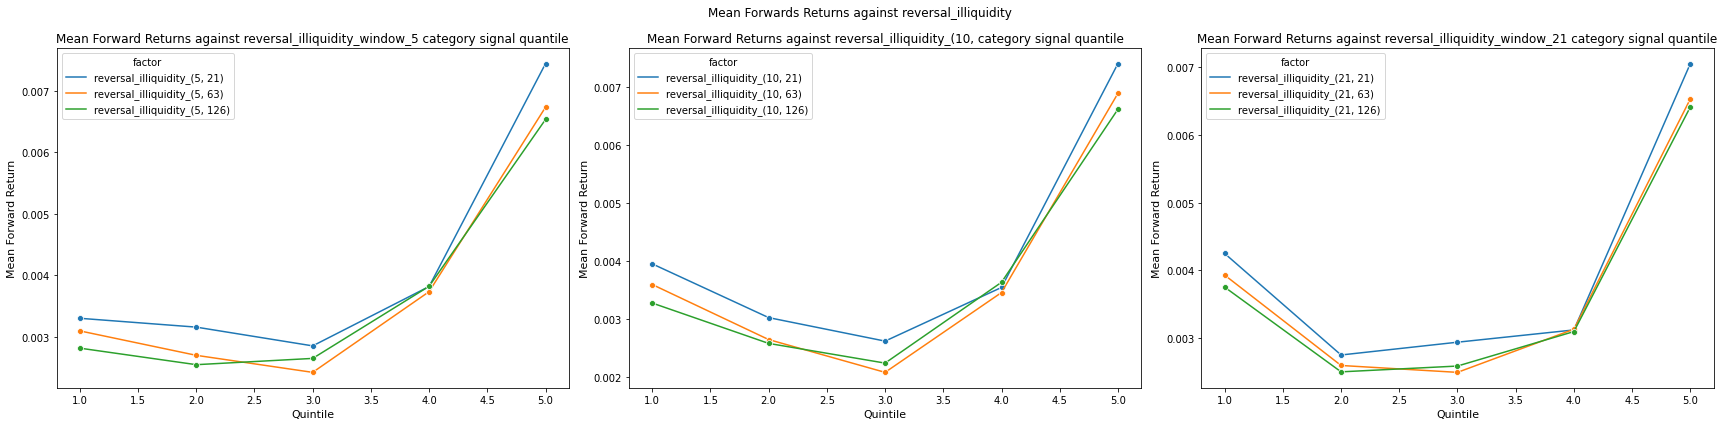

In [53]:
plot_quintiles(ri_results_quintile_dict, ri_summary_quintile_dict, "reversal_illiquidity")

### Correlation

In [54]:
reversal_illiquidity_df = factors_df_dict["reversal_illiquidity"]
reversal_window_5_list = [col for col in reversal_illiquidity_df if col.startswith("reversal_illiquidity_(5")]
reversal_window_10_list = [col for col in reversal_illiquidity_df if col.startswith("reversal_illiquidity_(10")]
reversal_window_21_list = [col for col in reversal_illiquidity_df if col.startswith("reversal_illiquidity_(21")]
reversal_5_illiquidity = reversal_illiquidity_df[reversal_window_5_list].corr("spearman")
reversal_10_illiquidity = reversal_illiquidity_df[reversal_window_10_list].corr("spearman")
reversal_21_illiquidity = reversal_illiquidity_df[reversal_window_21_list].corr("spearman")

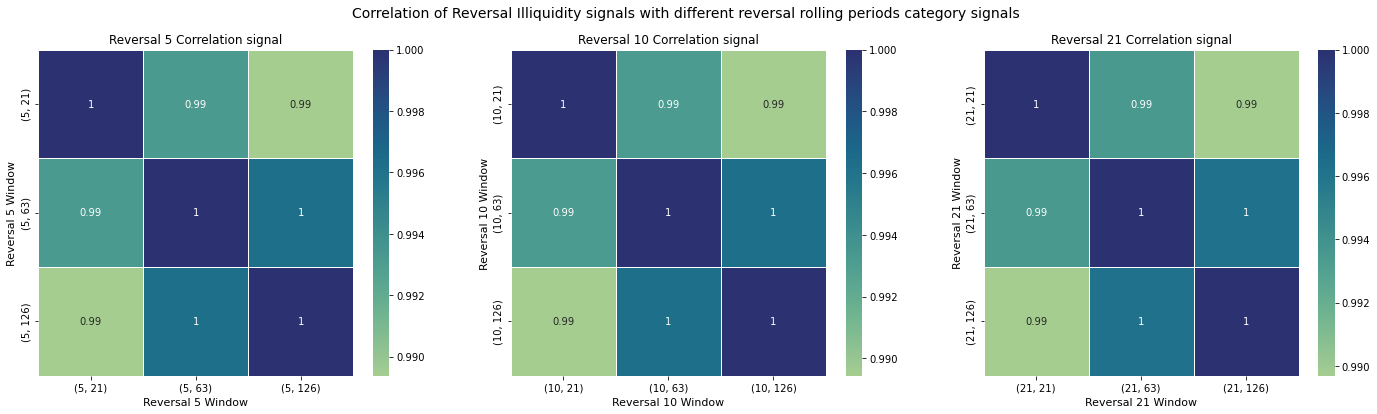

In [56]:
correlation_dfs_dict = {
    "Reversal 5": reversal_5_illiquidity,
    "Reversal 10": reversal_10_illiquidity, 
    "Reversal 21": reversal_21_illiquidity
}

fig, axs = plot_correlation(correlation_dfs_dict, "Reversal Illiquidity signals with different reversal rolling periods")

### PVO

In [39]:
pvo_results_ic_dict, pvo_summary_ic_df = results_ic_dict["pvo"], summary_ic_dict["pvo"]

In [42]:
pvo_summary_ic_df

,"pvo_((0.01, 0.99), (26, 12))"
ic_ir,0.055447
mean_ic,0.005391
n_periods,1006.000000
positive_ic_rate,0.504970
std_ic,0.097222


In [44]:
plot_ic_timeseries(pvo_results_ic_dict, "pvo")

KeyError: 'pvo'

In [85]:
predictive_factors_dict = {
    "beta": beta_factors,
    "mean_volatility": mv_factors,
    "microstructure": microstructure_factors,
    "momentum": momentum_factors,
    "momentum_liquidity": momentum_liquidity_factors, 
    "reversal": reversal_factors
}

new_df_list = []
for signal, factor_list in predictive_factors_dict.items(): 
    df = factors_df_dict[signal].copy() 
    final_df = df[factor_list]
    new_df_list.append(final_df)

final_df = pd.concat(new_df_list, axis=1)

In [86]:
final_df.corr()

,market_beta_63,industry_beta_63,market_resid_vol_126,industry_resid_vol_126,mean_volatility_10,mean_volatility_21,mean_volatility_63,amihud_21,momentum_252_21,momentum_liquidity_21,reversal_5,rsr_21
market_beta_63,1.000000,0.472966,0.276084,0.224247,0.116096,0.150652,0.197258,0.003663,0.121527,0.067101,-0.010864,0.026074
industry_beta_63,0.472966,1.000000,0.306715,0.101948,0.129483,0.168419,0.258466,-0.147596,0.106795,-0.033169,-0.013406,0.000967
market_resid_vol_126,0.276084,0.306715,1.000000,0.914887,0.098496,0.136566,0.204946,0.510103,0.233515,0.426340,-0.022498,0.029926
industry_resid_vol_126,0.224247,0.101948,0.914887,1.000000,0.074547,0.101103,0.151030,0.579108,0.224869,0.475127,-0.024691,0.027203
mean_volatility_10,0.116096,0.129483,0.098496,0.074547,1.000000,0.681028,0.375381,0.060058,-0.050344,-0.010104,-0.042770,-0.023247
mean_volatility_21,0.150652,0.168419,0.136566,0.101103,0.681028,1.000000,0.550471,0.060249,-0.068775,-0.025593,-0.033860,-0.049008
mean_volatility_63,0.197258,0.258466,0.204946,0.151030,0.375381,0.550471,1.000000,0.036048,-0.085131,-0.047120,-0.018307,-0.023644
amihud_21,0.003663,-0.147596,0.510103,0.579108,0.060058,0.060249,0.036048,1.000000,0.084526,0.676491,-0.011469,0.032681
momentum_252_21,0.121527,0.106795,0.233515,0.224869,-0.050344,-0.068775,-0.085131,0.084526,1.000000,0.720531,-0.048110,0.032287
momentum_liquidity_21,0.067101,-0.033169,0.426340,0.475127,-0.010104,-0.025593,-0.047120,0.676491,0.720531,1.000000,-0.038201,0.031549
